In [1]:
!pip install torch-geometric networkx

In [2]:
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/MyDrive/data-swow.graphml'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import random
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score, roc_curve
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data

In [4]:
G_directed_weighted = nx.read_graphml(path)
G = nx.Graph()
G.add_nodes_from(G_directed_weighted.nodes())
G.add_edges_from(G_directed_weighted.edges())

### 1. Cравнение GNN с простейшей моделью, основанной на лог. регрессии и структурных признаках для неориетированного, невзешенного графа

In [5]:
def normalize_edge(u, v):
    return tuple(sorted((u, v)))

RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.1

In [6]:
# positive edges

pos_edges = [normalize_edge(u, v) for u, v in G.edges()]

train_pos_edges, temp_pos_edges = train_test_split(
    pos_edges,
    test_size=TEST_SIZE + VAL_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

val_pos_edges, test_pos_edges = train_test_split(
    temp_pos_edges,
    test_size=TEST_SIZE / (TEST_SIZE + VAL_SIZE),
    random_state=RANDOM_STATE,
    shuffle=True
)

G_train = nx.Graph()
G_train.add_nodes_from(G.nodes())
G_train.add_edges_from(train_pos_edges)

print("Positive edges:")
print("train:", len(train_pos_edges))
print("val:", len(val_pos_edges))
print("test:", len(test_pos_edges))


Positive edges:
train: 246682
val: 35240
test: 70481


In [7]:
# negative

def sample_neg_edges(G, n_samples, seed, banned_edges=None):
    rng = random.Random(seed)
    nodes = list(G.nodes())
    neg_edges = set()
    banned_edges = banned_edges or set()
    
    while len(neg_edges) < n_samples:
        u, v = rng.sample(nodes, 2)
        edge = normalize_edge(u, v)

        if G.has_edge(u, v) or edge in banned_edges:
            continue

        neg_edges.add(edge)

    return list(neg_edges)

In [8]:
neg_edges = sample_neg_edges(
    G,
    n_samples=len(pos_edges),
    seed=RANDOM_STATE + 1
)

train_neg_edges, temp_neg_edges = train_test_split(
    neg_edges,
    test_size=TEST_SIZE + VAL_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

val_neg_edges, test_neg_edges = train_test_split(
    temp_neg_edges,
    test_size=TEST_SIZE / (TEST_SIZE + VAL_SIZE),
    random_state=RANDOM_STATE,
    shuffle=True
)

print("Negative edges:")
print("train:", len(train_neg_edges))
print("val:", len(val_neg_edges))
print("test:", len(test_neg_edges))


Negative edges:
train: 246682
val: 35240
test: 70481


In [9]:
train_edges = train_pos_edges + train_neg_edges
train_labels = np.array([1] * len(train_pos_edges) + [0] * len(train_neg_edges))

val_edges = val_pos_edges + val_neg_edges
val_labels = np.array([1] * len(val_pos_edges) + [0] * len(val_neg_edges))

test_edges = test_pos_edges + test_neg_edges
test_labels = np.array([1] * len(test_pos_edges) + [0] * len(test_neg_edges))


Теперь реализуем простую модель: логистическая регрессия на 3 структурных признаках(число общих сосоедей, коэффициент Жаккара, коэффициент Адамика-Адара)

In [10]:
def edge_features(G, edges):
    cn_scores = [len(list(nx.common_neighbors(G, u, v))) for u, v in edges]
    jaccard_scores = [score for _, _, score in nx.jaccard_coefficient(G, edges)]
    adamic_adar_scores = [score for _, _, score in nx.adamic_adar_index(G, edges)]

    return np.array(list(zip(cn_scores, jaccard_scores, adamic_adar_scores)))


In [11]:
X_train = edge_features(G_train, train_edges)
X_val = edge_features(G_train, val_edges)
X_test = edge_features(G_train, test_edges)

print(X_train.shape, train_labels.shape)
print(X_val.shape, val_labels.shape)
print(X_test.shape, test_labels.shape)


(493364, 3) (493364,)
(70480, 3) (70480,)
(140962, 3) (140962,)


In [12]:
C_VALUES = [0.01, 0.1, 1.0, 10.0, 100.0]
logreg_results = []
best_c = None
best_val_auc = -1.0
baseline_model = None

for c_value in C_VALUES:
    candidate_model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            C=c_value,
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])

    candidate_model.fit(X_train, train_labels)
    val_score = candidate_model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(val_labels, val_score)
    val_ap = average_precision_score(val_labels, val_score)

    logreg_results.append({
        "C": c_value,
        "val_roc_auc": val_auc,
        "val_average_precision": val_ap
    })

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_c = c_value
        baseline_model = candidate_model

logreg_results = pd.DataFrame(logreg_results)
logreg_results

,C,val_roc_auc,val_average_precision
0,0.01,0.855244,0.864268
1,0.10,0.855285,0.864425
2,1.00,0.855293,0.864459
3,10.00,0.855294,0.864463
4,100.00,0.855294,0.864464


In [13]:
print(f"Best C: {best_c}")
print(f"Best validation ROC-AUC: {best_val_auc:.4f}")

Best C: 100.0
Best validation ROC-AUC: 0.8553


In [14]:
y_score = baseline_model.predict_proba(X_test)[:, 1]
y_pred = (y_score >= 0.5).astype(int)

In [15]:
roc_auc = roc_auc_score(test_labels, y_score)
avg_precision = average_precision_score(test_labels, y_score)
accuracy = accuracy_score(test_labels, y_pred)
f1 = f1_score(test_labels, y_pred)

print(f"LogReg Test ROC-AUC: {roc_auc:.4f}")
print(f"LogReg Test Average Precision: {avg_precision:.4f}")
print(f"LogReg Test Accuracy, порог=0.5: {accuracy:.4f}")
print(f"LogReg Test F1-score, порог=0.5: {f1:.4f}")

LogReg Test ROC-AUC: 0.8543
LogReg Test Average Precision: 0.8636
LogReg Test Accuracy, порог=0.5: 0.8129
LogReg Test F1-score, порог=0.5: 0.7945


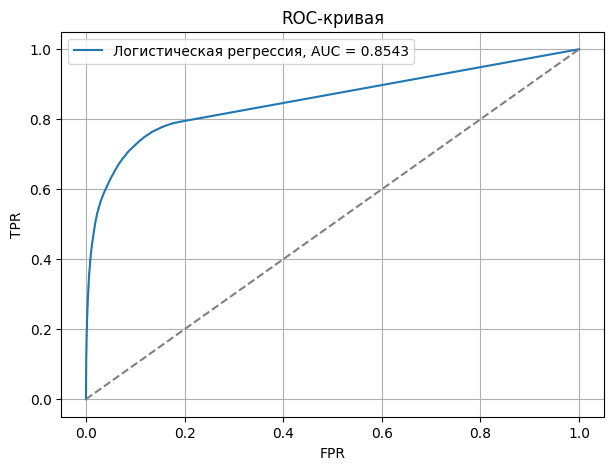

In [16]:
fpr, tpr, _ = roc_curve(test_labels, y_score)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Логистическая регрессия, AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC-кривая")
plt.legend()
plt.grid(True)
plt.show()


Теперь реализуем GNN

In [17]:
nodes = list(G_train.nodes())

node_to_id = {node: i for i, node in enumerate(nodes)}
id_to_node = {i: node for node, i in node_to_id.items()}

num_nodes = len(nodes)

print("Количество вершин:", num_nodes)

Количество вершин: 12217


In [ ]:
def edges_to_ids(edges, node_to_id):
    src = [node_to_id[u] for u, v in edges]
    dst = [node_to_id[v] for u, v in edges]

    return (torch.tensor(src, dtype=torch.long), torch.tensor(dst, dtype=torch.long))


In [19]:
graph_edges = list(G_train.edges())
graph_src, graph_dst = edges_to_ids(graph_edges, node_to_id)

edge_index = torch.stack([
    torch.cat([graph_src, graph_dst]),
    torch.cat([graph_dst, graph_src])
], dim=0)

data = Data(
    edge_index=edge_index,
    num_nodes=num_nodes
)

print(data)


Data(edge_index=[2, 493364], num_nodes=12217)


In [20]:
train_src, train_dst = edges_to_ids(train_edges, node_to_id)
val_src, val_dst = edges_to_ids(val_edges, node_to_id)
test_src, test_dst = edges_to_ids(test_edges, node_to_id)

train_edge_index = torch.stack([train_src, train_dst], dim=0)
val_edge_index = torch.stack([val_src, val_dst], dim=0)
test_edge_index = torch.stack([test_src, test_dst], dim=0)

train_y = torch.tensor(train_labels, dtype=torch.float32)
val_y = torch.tensor(val_labels, dtype=torch.float32)
test_y = torch.tensor(test_labels, dtype=torch.float32)

print(train_edge_index.shape, train_y.shape)
print(val_edge_index.shape, val_y.shape)
print(test_edge_index.shape, test_y.shape)


torch.Size([2, 493364]) torch.Size([493364])
torch.Size([2, 70480]) torch.Size([70480])
torch.Size([2, 140962]) torch.Size([140962])


In [21]:
class GraphSAGELinkPredictor(nn.Module):
    def __init__(self, num_nodes, emb_dim=64, hidden_dim=64, out_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, emb_dim)
        self.conv1 = SAGEConv(emb_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)

    def encode(self, edge_index):
        x = self.embedding.weight
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = self.conv2(h, edge_index)

        return h
    
    def decode(self, z, edge_label_index):
        src = edge_label_index[0]
        dst = edge_label_index[1]

        return (z[src] * z[dst]).sum(dim=1)
    
    def forward(self, edge_index, edge_label_index):
        z = self.encode(edge_index)
        scores = self.decode(z, edge_label_index)

        return scores

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [23]:
data = data.to(device)

train_edge_index = train_edge_index.to(device)
val_edge_index = val_edge_index.to(device)
test_edge_index = test_edge_index.to(device)

train_y = train_y.to(device)
val_y = val_y.to(device)
test_y = test_y.to(device)

gnn_model = GraphSAGELinkPredictor(
    num_nodes=num_nodes,
    emb_dim=128,
    hidden_dim=128,
    out_dim=64
).to(device)

optimizer = torch.optim.Adam(
    gnn_model.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

loss_func = nn.BCEWithLogitsLoss()


In [24]:
EPOCH_NUM = 10000
EVAL_EVERY = 50
PATIENCE = 500

best_val_auc = 0.0
best_val_ap = 0.0
best_epoch = 0
best_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCH_NUM + 1):
    gnn_model.train()
    optimizer.zero_grad()

    logits = gnn_model(data.edge_index, train_edge_index)
    loss = loss_func(logits, train_y)

    loss.backward()
    optimizer.step()

    if epoch % EVAL_EVERY == 0:
        gnn_model.eval()

        with torch.no_grad():
            val_logits = gnn_model(data.edge_index, val_edge_index)
            val_scores = torch.sigmoid(val_logits).detach().cpu().numpy()

        val_auc = roc_auc_score(val_labels, val_scores)
        val_ap = average_precision_score(val_labels, val_scores)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_val_ap = val_ap
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in gnn_model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += EVAL_EVERY

        print(
            f"Epoch {epoch:05d} | "
            f"Loss: {loss.item():.4f} | "
            f"Val ROC-AUC: {val_auc:.4f} | "
            f"Val AP: {val_ap:.4f} | "
            f"Best val ROC-AUC: {best_val_auc:.4f} at epoch {best_epoch}"
        )

        if epochs_without_improvement >= PATIENCE:
            print(f"Stopped at epoch {epoch}")
            break

if best_state is not None:
    gnn_model.load_state_dict(best_state)
    gnn_model = gnn_model.to(device)
    print(f"Best model from epoch {best_epoch}")


Epoch 00050 | Loss: 0.6899 | Val ROC-AUC: 0.5141 | Val AP: 0.5079 | Best val ROC-AUC: 0.5141 at epoch 50
Epoch 00100 | Loss: 0.6737 | Val ROC-AUC: 0.5285 | Val AP: 0.5219 | Best val ROC-AUC: 0.5285 at epoch 100
Epoch 00150 | Loss: 0.6553 | Val ROC-AUC: 0.5442 | Val AP: 0.5378 | Best val ROC-AUC: 0.5442 at epoch 150
Epoch 00200 | Loss: 0.6316 | Val ROC-AUC: 0.5666 | Val AP: 0.5579 | Best val ROC-AUC: 0.5666 at epoch 200
Epoch 00250 | Loss: 0.6034 | Val ROC-AUC: 0.6018 | Val AP: 0.5907 | Best val ROC-AUC: 0.6018 at epoch 250
Epoch 00300 | Loss: 0.5770 | Val ROC-AUC: 0.6341 | Val AP: 0.6217 | Best val ROC-AUC: 0.6341 at epoch 300
Epoch 00350 | Loss: 0.5556 | Val ROC-AUC: 0.6548 | Val AP: 0.6418 | Best val ROC-AUC: 0.6548 at epoch 350
Epoch 00400 | Loss: 0.5376 | Val ROC-AUC: 0.6688 | Val AP: 0.6562 | Best val ROC-AUC: 0.6688 at epoch 400
Epoch 00450 | Loss: 0.5219 | Val ROC-AUC: 0.6786 | Val AP: 0.6668 | Best val ROC-AUC: 0.6786 at epoch 450
Epoch 00500 | Loss: 0.5079 | Val ROC-AUC: 0.685

In [25]:
gnn_model.eval()

with torch.no_grad():
    test_logits = gnn_model(data.edge_index, test_edge_index)
    gnn_scores = torch.sigmoid(test_logits).detach().cpu().numpy()

gnn_pred = (gnn_scores >= 0.5).astype(int)

gnn_roc_auc = roc_auc_score(test_labels, gnn_scores)
gnn_avg_precision = average_precision_score(test_labels, gnn_scores)
gnn_accuracy = accuracy_score(test_labels, gnn_pred)
gnn_f1 = f1_score(test_labels, gnn_pred)

print(f"Best validation epoch: {best_epoch}")
print(f"Best validation ROC-AUC: {best_val_auc:.4f}")
print(f"Best validation Average Precision: {best_val_ap:.4f}")
print(f"Test ROC-AUC: {gnn_roc_auc:.4f}")
print(f"Test Average Precision: {gnn_avg_precision:.4f}")
print(f"Test Accuracy: {gnn_accuracy:.4f}")
print(f"Test F1-score: {gnn_f1:.4f}")


Best validation epoch: 700
Best validation ROC-AUC: 0.6952
Best validation Average Precision: 0.6861
Test ROC-AUC: 0.6975
Test Average Precision: 0.6878
Test Accuracy: 0.6318
Test F1-score: 0.6768


Результаты сравнения по ROC-AUC и Average Precision

In [26]:
test_results = pd.DataFrame([
    {
        "model": "LogReg",
        "roc_auc": roc_auc,
        "average_precision": avg_precision,
        "accuracy": accuracy,
        "f1": f1,
    },
    {
        "model": "GNN",
        "roc_auc": gnn_roc_auc,
        "average_precision": gnn_avg_precision,
        "accuracy": gnn_accuracy,
        "f1": gnn_f1,
    }
])
test_results.round(4)

,model,roc_auc,average_precision,accuracy,f1
0,LogReg,0.8543,0.8636,0.8129,0.7945
1,GNN,0.6975,0.6878,0.6318,0.6768


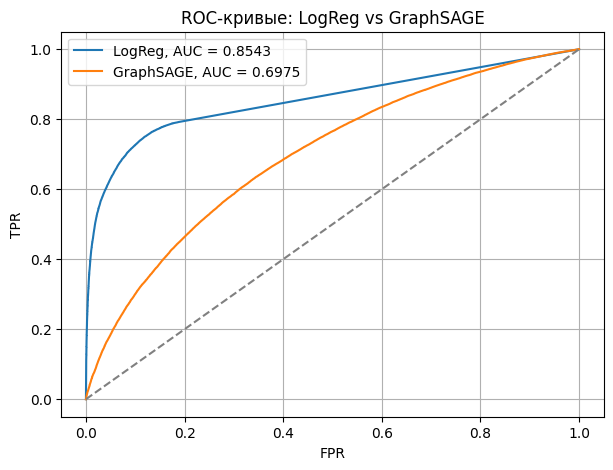

In [27]:
logreg_fpr, logreg_tpr, _ = roc_curve(test_labels, y_score)
gnn_fpr, gnn_tpr, _ = roc_curve(test_labels, gnn_scores)

plt.figure(figsize=(7, 5))
plt.plot(logreg_fpr, logreg_tpr, label=f"LogReg, AUC = {roc_auc:.4f}")
plt.plot(gnn_fpr, gnn_tpr, label=f"GraphSAGE, AUC = {gnn_roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC-кривые: LogReg vs GraphSAGE")
plt.legend()
plt.grid(True)
plt.show()


### 2.1. Для теста и валидации возьмем 30% самых больших по весу ребер

In [28]:
edge_weights = {}

for u, v, edge_data in G_directed_weighted.edges(data=True):
    edge = normalize_edge(u, v)
    w = float(edge_data['R1.Strength'])

    if edge not in edge_weights:
        edge_weights[edge] = w
    else:
        edge_weights[edge] = max(edge_weights[edge], w)

In [29]:
sorted_w_edges = sorted(edge_weights.items(), key=lambda x: x[1], reverse=True)

n_strong = int(len(sorted_w_edges) * (TEST_SIZE + VAL_SIZE))
strong_edges = [edge for edge, weight in sorted_w_edges[:n_strong]]
train_pos_edges = [edge for edge, weight in sorted_w_edges[n_strong:]]

val_pos_edges, test_pos_edges = train_test_split(
    strong_edges,
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    random_state=RANDOM_STATE,
    shuffle=True
)

In [30]:
train_neg_edges = sample_neg_edges(G, n_samples=len(train_pos_edges), seed=RANDOM_STATE + 1)
val_neg_edges = sample_neg_edges(G, n_samples=len(val_pos_edges), 
                                 seed=RANDOM_STATE + 2, banned_edges=set(train_neg_edges))
test_neg_edges = sample_neg_edges(G, n_samples=len(test_pos_edges),
                                  seed=RANDOM_STATE + 3, banned_edges=set(train_neg_edges) | set(val_neg_edges))


In [31]:
train_edges = train_pos_edges + train_neg_edges
train_labels = np.array([1] * len(train_pos_edges) + [0] * len(train_neg_edges))

val_edges = val_pos_edges + val_neg_edges
val_labels = np.array([1] * len(val_pos_edges) + [0] * len(val_neg_edges))

test_edges = test_pos_edges + test_neg_edges
test_labels = np.array([1] * len(test_pos_edges) + [0] * len(test_neg_edges))


In [32]:
G_train = nx.Graph()
G_train.add_nodes_from(G.nodes())
G_train.add_edges_from(train_pos_edges)

In [33]:
X_train = edge_features(G_train, train_edges)
X_val = edge_features(G_train, val_edges)
X_test = edge_features(G_train, test_edges)

print(X_train.shape, train_labels.shape)
print(X_val.shape, val_labels.shape)
print(X_test.shape, test_labels.shape)

(493366, 3) (493366,)
(70480, 3) (70480,)
(140960, 3) (140960,)


In [34]:
C_VALUES = [0.01, 0.1, 1.0, 10.0, 100.0]
logreg_results = []
best_c = None
best_val_auc = -1.0
baseline_model = None

for c_value in C_VALUES:
    candidate_model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            C=c_value,
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])

    candidate_model.fit(X_train, train_labels)
    val_score = candidate_model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(val_labels, val_score)
    val_ap = average_precision_score(val_labels, val_score)

    logreg_results.append({
        "C": c_value,
        "val_roc_auc": val_auc,
        "val_average_precision": val_ap
    })

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_c = c_value
        baseline_model = candidate_model

logreg_results = pd.DataFrame(logreg_results)
logreg_results

,C,val_roc_auc,val_average_precision
0,0.01,0.859247,0.865993
1,0.10,0.859435,0.866300
2,1.00,0.859454,0.866333
3,10.00,0.859456,0.866337
4,100.00,0.859456,0.866338


In [35]:
print(f"Best C: {best_c}")
print(f"Best validation ROC-AUC: {best_val_auc:.4f}")

Best C: 100.0
Best validation ROC-AUC: 0.8595


In [36]:
y_score = baseline_model.predict_proba(X_test)[:, 1]
y_pred = (y_score >= 0.5).astype(int)

In [37]:
roc_auc = roc_auc_score(test_labels, y_score)
avg_precision = average_precision_score(test_labels, y_score)
accuracy = accuracy_score(test_labels, y_pred)
f1 = f1_score(test_labels, y_pred)

print(f"LogReg Test ROC-AUC: {roc_auc:.4f}")
print(f"LogReg Test Average Precision: {avg_precision:.4f}")
print(f"LogReg Test Accuracy, порог=0.5: {accuracy:.4f}")
print(f"LogReg Test F1-score, порог=0.5: {f1:.4f}")

LogReg Test ROC-AUC: 0.8571
LogReg Test Average Precision: 0.8647
LogReg Test Accuracy, порог=0.5: 0.8192
LogReg Test F1-score, порог=0.5: 0.8106


In [38]:
logreg_roc_auc_strong = roc_auc
logreg_avg_precision_strong = avg_precision
logreg_accuracy_strong = accuracy
logreg_f1_strong = f1
logreg_y_score_strong = y_score


In [39]:
nodes = list(G_train.nodes())

node_to_id = {node: i for i, node in enumerate(nodes)}
id_to_node = {i: node for node, i in node_to_id.items()}

num_nodes = len(nodes)

print("Количество вершин:", num_nodes)

Количество вершин: 12217


In [40]:
graph_edges = list(G_train.edges())
graph_src, graph_dst = edges_to_ids(graph_edges, node_to_id)

edge_index = torch.stack([
    torch.cat([graph_src, graph_dst]),
    torch.cat([graph_dst, graph_src])
], dim=0)

strong_data = Data(
    edge_index=edge_index,
    num_nodes=num_nodes
)

print(strong_data)


Data(edge_index=[2, 493366], num_nodes=12217)


In [41]:
train_src, train_dst = edges_to_ids(train_edges, node_to_id)
val_src, val_dst = edges_to_ids(val_edges, node_to_id)
test_src, test_dst = edges_to_ids(test_edges, node_to_id)

train_edge_index = torch.stack([train_src, train_dst], dim=0)
val_edge_index = torch.stack([val_src, val_dst], dim=0)
test_edge_index = torch.stack([test_src, test_dst], dim=0)

train_y = torch.tensor(train_labels, dtype=torch.float32)
val_y = torch.tensor(val_labels, dtype=torch.float32)
test_y = torch.tensor(test_labels, dtype=torch.float32)

print(train_edge_index.shape, train_y.shape)
print(val_edge_index.shape, val_y.shape)
print(test_edge_index.shape, test_y.shape)


torch.Size([2, 493366]) torch.Size([493366])
torch.Size([2, 70480]) torch.Size([70480])
torch.Size([2, 140960]) torch.Size([140960])


In [42]:
strong_data = strong_data.to(device)

train_edge_index = train_edge_index.to(device)
val_edge_index = val_edge_index.to(device)
test_edge_index = test_edge_index.to(device)

train_y = train_y.to(device)
val_y = val_y.to(device)
test_y = test_y.to(device)

gnn_model = GraphSAGELinkPredictor(
    num_nodes=num_nodes,
    emb_dim=128,
    hidden_dim=128,
    out_dim=64
).to(device)

optimizer = torch.optim.Adam(
    gnn_model.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

loss_func = nn.BCEWithLogitsLoss()


In [43]:
EPOCH_NUM = 10000
EVAL_EVERY = 50
PATIENCE = 500

best_val_auc = 0.0
best_val_ap = 0.0
best_epoch = 0
best_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCH_NUM + 1):
    gnn_model.train()
    optimizer.zero_grad()

    logits = gnn_model(strong_data.edge_index, train_edge_index)
    loss = loss_func(logits, train_y)

    loss.backward()
    optimizer.step()

    if epoch % EVAL_EVERY == 0:
        gnn_model.eval()

        with torch.no_grad():
            val_logits = gnn_model(strong_data.edge_index, val_edge_index)
            val_scores = torch.sigmoid(val_logits).detach().cpu().numpy()

        val_auc = roc_auc_score(val_labels, val_scores)
        val_ap = average_precision_score(val_labels, val_scores)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_val_ap = val_ap
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in gnn_model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += EVAL_EVERY

        print(
            f"Epoch {epoch:05d} | "
            f"Loss: {loss.item():.4f} | "
            f"Val ROC-AUC: {val_auc:.4f} | "
            f"Val AP: {val_ap:.4f} | "
            f"Best val ROC-AUC: {best_val_auc:.4f} at epoch {best_epoch}"
        )

        if epochs_without_improvement >= PATIENCE:
            print(f"Stopped at epoch {epoch}")
            break

if best_state is not None:
    gnn_model.load_state_dict(best_state)
    gnn_model = gnn_model.to(device)
    print(f"Best model from epoch {best_epoch}")


Epoch 00050 | Loss: 0.6910 | Val ROC-AUC: 0.5104 | Val AP: 0.5048 | Best val ROC-AUC: 0.5104 at epoch 50
Epoch 00100 | Loss: 0.6759 | Val ROC-AUC: 0.5235 | Val AP: 0.5154 | Best val ROC-AUC: 0.5235 at epoch 100
Epoch 00150 | Loss: 0.6600 | Val ROC-AUC: 0.5385 | Val AP: 0.5292 | Best val ROC-AUC: 0.5385 at epoch 150
Epoch 00200 | Loss: 0.6410 | Val ROC-AUC: 0.5559 | Val AP: 0.5450 | Best val ROC-AUC: 0.5559 at epoch 200
Epoch 00250 | Loss: 0.6186 | Val ROC-AUC: 0.5824 | Val AP: 0.5702 | Best val ROC-AUC: 0.5824 at epoch 250
Epoch 00300 | Loss: 0.5952 | Val ROC-AUC: 0.6153 | Val AP: 0.6025 | Best val ROC-AUC: 0.6153 at epoch 300
Epoch 00350 | Loss: 0.5744 | Val ROC-AUC: 0.6412 | Val AP: 0.6283 | Best val ROC-AUC: 0.6412 at epoch 350
Epoch 00400 | Loss: 0.5564 | Val ROC-AUC: 0.6596 | Val AP: 0.6469 | Best val ROC-AUC: 0.6596 at epoch 400
Epoch 00450 | Loss: 0.5403 | Val ROC-AUC: 0.6731 | Val AP: 0.6608 | Best val ROC-AUC: 0.6731 at epoch 450
Epoch 00500 | Loss: 0.5256 | Val ROC-AUC: 0.683

In [44]:
gnn_model.eval()

with torch.no_grad():
    test_logits = gnn_model(strong_data.edge_index, test_edge_index)
    gnn_scores_strong = torch.sigmoid(test_logits).detach().cpu().numpy()

gnn_pred_strong = (gnn_scores_strong >= 0.5).astype(int)

gnn_roc_auc_strong = roc_auc_score(test_labels, gnn_scores_strong)
gnn_avg_precision_strong = average_precision_score(test_labels, gnn_scores_strong)
gnn_accuracy_strong = accuracy_score(test_labels, gnn_pred_strong)
gnn_f1_strong = f1_score(test_labels, gnn_pred_strong)

print(f"Best validation epoch: {best_epoch}")
print(f"Best validation ROC-AUC: {best_val_auc:.4f}")
print(f"Best validation Average Precision: {best_val_ap:.4f}")
print(f"Test ROC-AUC: {gnn_roc_auc_strong:.4f}")
print(f"Test Average Precision: {gnn_avg_precision_strong:.4f}")
print(f"Test Accuracy: {gnn_accuracy_strong:.4f}")
print(f"Test F1-score: {gnn_f1_strong:.4f}")


Best validation epoch: 750
Best validation ROC-AUC: 0.6999
Best validation Average Precision: 0.6880
Test ROC-AUC: 0.6979
Test Average Precision: 0.6869
Test Accuracy: 0.6331
Test F1-score: 0.6790


In [45]:
strong_edges_results = pd.DataFrame([
    {
        "model": "LogReg",
        "roc_auc": logreg_roc_auc_strong,
        "average_precision": logreg_avg_precision_strong,
        "accuracy": logreg_accuracy_strong,
        "f1": logreg_f1_strong,
    },
    {
        "model": "GNN",
        "roc_auc": gnn_roc_auc_strong,
        "average_precision": gnn_avg_precision_strong,
        "accuracy": gnn_accuracy_strong,
        "f1": gnn_f1_strong,
    }
])

strong_edges_results.round(4)


,model,roc_auc,average_precision,accuracy,f1
0,LogReg,0.8571,0.8647,0.8192,0.8106
1,GNN,0.6979,0.6869,0.6331,0.6790


In [46]:
all_results = pd.concat([
    test_results.assign(experiment="Random split"),
    strong_edges_results.assign(experiment="Strong edges split")
], ignore_index=True)

all_results[["experiment", "model", "roc_auc", "average_precision", "accuracy", "f1"]].round(4)


,experiment,model,roc_auc,average_precision,accuracy,f1
0,Random split,LogReg,0.8543,0.8636,0.8129,0.7945
1,Random split,GNN,0.6975,0.6878,0.6318,0.6768
2,Strong edges split,LogReg,0.8571,0.8647,0.8192,0.8106
3,Strong edges split,GNN,0.6979,0.6869,0.6331,0.6790


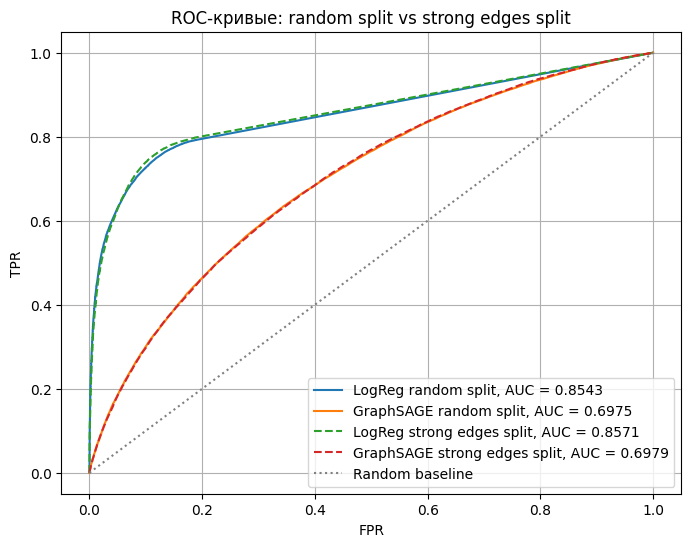

In [50]:
random_logreg_auc = test_results.loc[test_results["model"] == "LogReg", "roc_auc"].iloc[0]
random_gnn_auc = test_results.loc[test_results["model"] == "GNN", "roc_auc"].iloc[0]

logreg_fpr_strong, logreg_tpr_strong, _ = roc_curve(test_labels, logreg_y_score_strong)
gnn_fpr_strong, gnn_tpr_strong, _ = roc_curve(test_labels, gnn_scores_strong)

plt.figure(figsize=(8, 6))

plt.plot(
    logreg_fpr,
    logreg_tpr,
    label=f"LogReg random split, AUC = {random_logreg_auc:.4f}",
    linestyle="-"
)
plt.plot(
    gnn_fpr,
    gnn_tpr,
    label=f"GraphSAGE random split, AUC = {random_gnn_auc:.4f}",
    linestyle="-"
)
plt.plot(
    logreg_fpr_strong,
    logreg_tpr_strong,
    label=f"LogReg strong edges split, AUC = {logreg_roc_auc_strong:.4f}",
    linestyle="--"
)
plt.plot(
    gnn_fpr_strong,
    gnn_tpr_strong,
    label=f"GraphSAGE strong edges split, AUC = {gnn_roc_auc_strong:.4f}",
    linestyle="--"
)

plt.plot([0, 1], [0, 1], linestyle=":", color="gray", label="Random baseline")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC-кривые: random split vs strong edges split")
plt.legend()
plt.grid(True)
plt.show()


### 2.2. Для теста и валидации возьмем 30% самых маленьких по весу ребер


In [51]:
sorted_w_edges = sorted(edge_weights.items(), key=lambda x: x[1], reverse=True)

n_weak = int(len(sorted_w_edges) * (TEST_SIZE + VAL_SIZE))
weak_edges = [edge for edge, weight in sorted_w_edges[-n_weak:]]
train_pos_edges = [edge for edge, weight in sorted_w_edges[:-n_weak]]

val_pos_edges, test_pos_edges = train_test_split(
    weak_edges,
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    random_state=RANDOM_STATE,
    shuffle=True
)

print("Weak positive edges:", len(weak_edges))
print("Train positive edges:", len(train_pos_edges))
print("Validation positive edges:", len(val_pos_edges))
print("Test positive edges:", len(test_pos_edges))


Weak positive edges: 105720
Train positive edges: 246683
Validation positive edges: 35240
Test positive edges: 70480


In [52]:
train_neg_edges = sample_neg_edges(
    G,
    n_samples=len(train_pos_edges),
    seed=RANDOM_STATE + 1
)

val_neg_edges = sample_neg_edges(
    G,
    n_samples=len(val_pos_edges),
    seed=RANDOM_STATE + 2,
    banned_edges=set(train_neg_edges)
)

test_neg_edges = sample_neg_edges(
    G,
    n_samples=len(test_pos_edges),
    seed=RANDOM_STATE + 3,
    banned_edges=set(train_neg_edges) | set(val_neg_edges)
)


In [53]:
train_edges = train_pos_edges + train_neg_edges
train_labels = np.array([1] * len(train_pos_edges) + [0] * len(train_neg_edges))

val_edges = val_pos_edges + val_neg_edges
val_labels = np.array([1] * len(val_pos_edges) + [0] * len(val_neg_edges))

test_edges = test_pos_edges + test_neg_edges
test_labels = np.array([1] * len(test_pos_edges) + [0] * len(test_neg_edges))

print("Train labels:", np.bincount(train_labels))
print("Validation labels:", np.bincount(val_labels))
print("Test labels:", np.bincount(test_labels))


Train labels: [246683 246683]
Validation labels: [35240 35240]
Test labels: [70480 70480]


In [54]:
G_train = nx.Graph()
G_train.add_nodes_from(G.nodes())
G_train.add_edges_from(train_pos_edges)

print("G_train nodes:", G_train.number_of_nodes())
print("G_train edges:", G_train.number_of_edges())


G_train nodes: 12217
G_train edges: 246683


In [55]:
X_train = edge_features(G_train, train_edges)
X_val = edge_features(G_train, val_edges)
X_test = edge_features(G_train, test_edges)

print(X_train.shape, train_labels.shape)
print(X_val.shape, val_labels.shape)
print(X_test.shape, test_labels.shape)


(493366, 3) (493366,)
(70480, 3) (70480,)
(140960, 3) (140960,)


In [56]:
C_VALUES = [0.01, 0.1, 1.0, 10.0, 100.0]
logreg_results_weak = []
best_c_weak = None
best_logreg_val_auc_weak = -1.0
baseline_model_weak = None

for c_value in C_VALUES:
    candidate_model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            C=c_value,
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])

    candidate_model.fit(X_train, train_labels)
    val_score = candidate_model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(val_labels, val_score)
    val_ap = average_precision_score(val_labels, val_score)

    logreg_results_weak.append({
        "C": c_value,
        "val_roc_auc": val_auc,
        "val_average_precision": val_ap
    })

    if val_auc > best_logreg_val_auc_weak:
        best_logreg_val_auc_weak = val_auc
        best_c_weak = c_value
        baseline_model_weak = candidate_model

logreg_results_weak = pd.DataFrame(logreg_results_weak)
logreg_results_weak


,C,val_roc_auc,val_average_precision
0,0.01,0.781484,0.787531
1,0.10,0.781594,0.787979
2,1.00,0.781669,0.788215
3,10.00,0.781680,0.788247
4,100.00,0.781681,0.788250


In [57]:
print(f"Best C: {best_c_weak}")
print(f"Best validation ROC-AUC: {best_logreg_val_auc_weak:.4f}")


Best C: 100.0
Best validation ROC-AUC: 0.7817


In [58]:
logreg_y_score_weak = baseline_model_weak.predict_proba(X_test)[:, 1]
logreg_y_pred_weak = (logreg_y_score_weak >= 0.5).astype(int)

logreg_roc_auc_weak = roc_auc_score(test_labels, logreg_y_score_weak)
logreg_avg_precision_weak = average_precision_score(test_labels, logreg_y_score_weak)
logreg_accuracy_weak = accuracy_score(test_labels, logreg_y_pred_weak)
logreg_f1_weak = f1_score(test_labels, logreg_y_pred_weak)

print(f"LogReg Test ROC-AUC: {logreg_roc_auc_weak:.4f}")
print(f"LogReg Test Average Precision: {logreg_avg_precision_weak:.4f}")
print(f"LogReg Test Accuracy, порог=0.5: {logreg_accuracy_weak:.4f}")
print(f"LogReg Test F1-score, порог=0.5: {logreg_f1_weak:.4f}")


LogReg Test ROC-AUC: 0.7828
LogReg Test Average Precision: 0.7894
LogReg Test Accuracy, порог=0.5: 0.7311
LogReg Test F1-score, порог=0.5: 0.6651


Теперь обучим GNN на split, где validation/test состоят из 30% самых слабых рёбер.


In [59]:
nodes = list(G_train.nodes())

node_to_id = {node: i for i, node in enumerate(nodes)}
id_to_node = {i: node for node, i in node_to_id.items()}

num_nodes = len(nodes)

print("Количество вершин:", num_nodes)


Количество вершин: 12217


In [60]:
graph_edges = list(G_train.edges())
graph_src, graph_dst = edges_to_ids(graph_edges, node_to_id)

edge_index = torch.stack([
    torch.cat([graph_src, graph_dst]),
    torch.cat([graph_dst, graph_src])
], dim=0)

weak_data = Data(
    edge_index=edge_index,
    num_nodes=num_nodes
)

print(weak_data)


Data(edge_index=[2, 493366], num_nodes=12217)


In [61]:
train_src, train_dst = edges_to_ids(train_edges, node_to_id)
val_src, val_dst = edges_to_ids(val_edges, node_to_id)
test_src, test_dst = edges_to_ids(test_edges, node_to_id)

train_edge_index = torch.stack([train_src, train_dst], dim=0)
val_edge_index = torch.stack([val_src, val_dst], dim=0)
test_edge_index = torch.stack([test_src, test_dst], dim=0)

train_y = torch.tensor(train_labels, dtype=torch.float32)
val_y = torch.tensor(val_labels, dtype=torch.float32)
test_y = torch.tensor(test_labels, dtype=torch.float32)

print(train_edge_index.shape, train_y.shape)
print(val_edge_index.shape, val_y.shape)
print(test_edge_index.shape, test_y.shape)


torch.Size([2, 493366]) torch.Size([493366])
torch.Size([2, 70480]) torch.Size([70480])
torch.Size([2, 140960]) torch.Size([140960])


In [62]:
weak_data = weak_data.to(device)

train_edge_index = train_edge_index.to(device)
val_edge_index = val_edge_index.to(device)
test_edge_index = test_edge_index.to(device)

train_y = train_y.to(device)
val_y = val_y.to(device)
test_y = test_y.to(device)

gnn_model = GraphSAGELinkPredictor(
    num_nodes=num_nodes,
    emb_dim=128,
    hidden_dim=128,
    out_dim=64
).to(device)

optimizer = torch.optim.Adam(
    gnn_model.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

loss_func = nn.BCEWithLogitsLoss()


In [63]:
EPOCH_NUM = 10000
EVAL_EVERY = 50
PATIENCE = 500

best_val_auc = 0.0
best_val_ap = 0.0
best_epoch = 0
best_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCH_NUM + 1):
    gnn_model.train()
    optimizer.zero_grad()

    logits = gnn_model(weak_data.edge_index, train_edge_index)
    loss = loss_func(logits, train_y)

    loss.backward()
    optimizer.step()

    if epoch % EVAL_EVERY == 0:
        gnn_model.eval()

        with torch.no_grad():
            val_logits = gnn_model(weak_data.edge_index, val_edge_index)
            val_scores = torch.sigmoid(val_logits).detach().cpu().numpy()

        val_auc = roc_auc_score(val_labels, val_scores)
        val_ap = average_precision_score(val_labels, val_scores)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_val_ap = val_ap
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in gnn_model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += EVAL_EVERY

        print(
            f"Epoch {epoch:05d} | "
            f"Loss: {loss.item():.4f} | "
            f"Val ROC-AUC: {val_auc:.4f} | "
            f"Val AP: {val_ap:.4f} | "
            f"Best val ROC-AUC: {best_val_auc:.4f} at epoch {best_epoch}"
        )

        if epochs_without_improvement >= PATIENCE:
            print(f"Stopped at epoch {epoch}")
            break

if best_state is not None:
    gnn_model.load_state_dict(best_state)
    gnn_model = gnn_model.to(device)
    print(f"Best model from epoch {best_epoch}")


Epoch 00050 | Loss: 0.6906 | Val ROC-AUC: 0.5110 | Val AP: 0.5073 | Best val ROC-AUC: 0.5110 at epoch 50
Epoch 00100 | Loss: 0.6748 | Val ROC-AUC: 0.5230 | Val AP: 0.5189 | Best val ROC-AUC: 0.5230 at epoch 100
Epoch 00150 | Loss: 0.6565 | Val ROC-AUC: 0.5365 | Val AP: 0.5330 | Best val ROC-AUC: 0.5365 at epoch 150
Epoch 00200 | Loss: 0.6322 | Val ROC-AUC: 0.5561 | Val AP: 0.5526 | Best val ROC-AUC: 0.5561 at epoch 200
Epoch 00250 | Loss: 0.6033 | Val ROC-AUC: 0.5861 | Val AP: 0.5820 | Best val ROC-AUC: 0.5861 at epoch 250
Epoch 00300 | Loss: 0.5767 | Val ROC-AUC: 0.6141 | Val AP: 0.6090 | Best val ROC-AUC: 0.6141 at epoch 300
Epoch 00350 | Loss: 0.5551 | Val ROC-AUC: 0.6314 | Val AP: 0.6265 | Best val ROC-AUC: 0.6314 at epoch 350
Epoch 00400 | Loss: 0.5370 | Val ROC-AUC: 0.6426 | Val AP: 0.6387 | Best val ROC-AUC: 0.6426 at epoch 400
Epoch 00450 | Loss: 0.5211 | Val ROC-AUC: 0.6499 | Val AP: 0.6473 | Best val ROC-AUC: 0.6499 at epoch 450
Epoch 00500 | Loss: 0.5070 | Val ROC-AUC: 0.653

In [64]:
gnn_model.eval()

with torch.no_grad():
    test_logits = gnn_model(weak_data.edge_index, test_edge_index)
    gnn_scores_weak = torch.sigmoid(test_logits).detach().cpu().numpy()

gnn_pred_weak = (gnn_scores_weak >= 0.5).astype(int)

gnn_roc_auc_weak = roc_auc_score(test_labels, gnn_scores_weak)
gnn_avg_precision_weak = average_precision_score(test_labels, gnn_scores_weak)
gnn_accuracy_weak = accuracy_score(test_labels, gnn_pred_weak)
gnn_f1_weak = f1_score(test_labels, gnn_pred_weak)

print(f"Best validation epoch: {best_epoch}")
print(f"Best validation ROC-AUC: {best_val_auc:.4f}")
print(f"Best validation Average Precision: {best_val_ap:.4f}")
print(f"Test ROC-AUC: {gnn_roc_auc_weak:.4f}")
print(f"Test Average Precision: {gnn_avg_precision_weak:.4f}")
print(f"Test Accuracy: {gnn_accuracy_weak:.4f}")
print(f"Test F1-score: {gnn_f1_weak:.4f}")


Best validation epoch: 550
Best validation ROC-AUC: 0.6552
Best validation Average Precision: 0.6554
Test ROC-AUC: 0.6537
Test Average Precision: 0.6541
Test Accuracy: 0.6016
Test F1-score: 0.6420


In [65]:
weak_edges_results = pd.DataFrame([
    {
        "model": "LogReg",
        "roc_auc": logreg_roc_auc_weak,
        "average_precision": logreg_avg_precision_weak,
        "accuracy": logreg_accuracy_weak,
        "f1": logreg_f1_weak,
    },
    {
        "model": "GNN",
        "roc_auc": gnn_roc_auc_weak,
        "average_precision": gnn_avg_precision_weak,
        "accuracy": gnn_accuracy_weak,
        "f1": gnn_f1_weak,
    }
])

weak_edges_results.round(4)


,model,roc_auc,average_precision,accuracy,f1
0,LogReg,0.7828,0.7894,0.7311,0.6651
1,GNN,0.6537,0.6541,0.6016,0.6420


In [66]:
all_results = pd.concat([
    test_results.assign(experiment="Random split"),
    strong_edges_results.assign(experiment="Strong edges split"),
    weak_edges_results.assign(experiment="Weak edges split")
], ignore_index=True)

all_results[["experiment", "model", "roc_auc", "average_precision", "accuracy", "f1"]].round(4)


,experiment,model,roc_auc,average_precision,accuracy,f1
0,Random split,LogReg,0.8543,0.8636,0.8129,0.7945
1,Random split,GNN,0.6975,0.6878,0.6318,0.6768
2,Strong edges split,LogReg,0.8571,0.8647,0.8192,0.8106
3,Strong edges split,GNN,0.6979,0.6869,0.6331,0.6790
4,Weak edges split,LogReg,0.7828,0.7894,0.7311,0.6651
5,Weak edges split,GNN,0.6537,0.6541,0.6016,0.6420


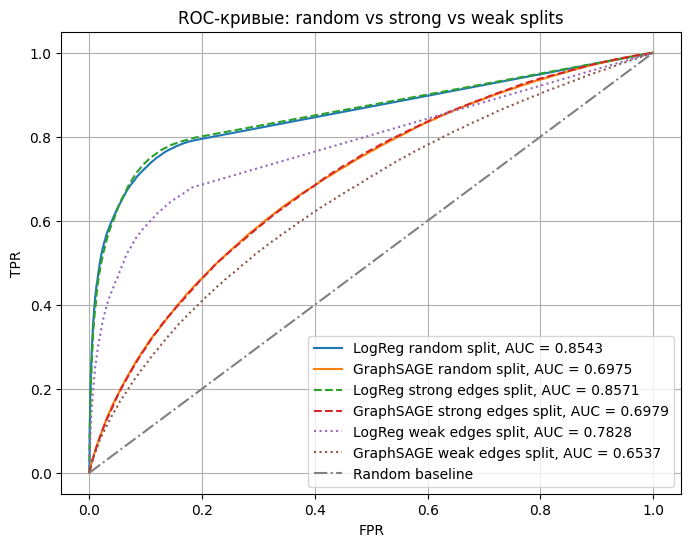

In [68]:
logreg_fpr_weak, logreg_tpr_weak, _ = roc_curve(test_labels, logreg_y_score_weak)
gnn_fpr_weak, gnn_tpr_weak, _ = roc_curve(test_labels, gnn_scores_weak)

plt.figure(figsize=(8, 6))

plt.plot(logreg_fpr, logreg_tpr, label=f"LogReg random split, AUC = {random_logreg_auc:.4f}", linestyle="-")
plt.plot(gnn_fpr, gnn_tpr, label=f"GraphSAGE random split, AUC = {random_gnn_auc:.4f}", linestyle="-")
plt.plot(logreg_fpr_strong, logreg_tpr_strong, label=f"LogReg strong edges split, AUC = {logreg_roc_auc_strong:.4f}", linestyle="--")
plt.plot(gnn_fpr_strong, gnn_tpr_strong, label=f"GraphSAGE strong edges split, AUC = {gnn_roc_auc_strong:.4f}", linestyle="--")
plt.plot(logreg_fpr_weak, logreg_tpr_weak, label=f"LogReg weak edges split, AUC = {logreg_roc_auc_weak:.4f}", linestyle=":")
plt.plot(gnn_fpr_weak, gnn_tpr_weak, label=f"GraphSAGE weak edges split, AUC = {gnn_roc_auc_weak:.4f}", linestyle=":")

plt.plot([0, 1], [0, 1], linestyle="-.", color="gray", label="Random baseline")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC-кривые: random vs strong vs weak splits")
plt.legend()
plt.grid(True)
plt.show()


Как видно, когда в validation и test попадают 30% самых сильных рёбер, качество моделей почти не меняется. Однако для 30% самых слабых рёбер качество падает у обеих моделей, что логично: слабые связи, скорее всего, имеют менее выраженные структурные признаки, поэтому моделям сложнее отличать их от отсутствующих рёбер.


### 3. Ориентированный граф


Для ориентированного графа структурные признаки можно обобщить, поэтому проблем с базовой моделью нет.

Для GNN механизм message passing все так же работает, однако скалярное произведение в качестве decoder не подойдет, т.к. оно симметрично. Поэтому можно сделать так: конкатенировать два эмбединга, а затем применить уже какой-то алгоритм для бинарной классификации, можно, например, использовать MLP.

In [6]:
G_directed = nx.DiGraph()
G_directed.add_nodes_from(G_directed_weighted.nodes())
G_directed.add_edges_from(G_directed_weighted.edges())

In [7]:
pos_edges_directed = list(G_directed.edges())

train_pos_edges, temp_pos_edges = train_test_split(
    pos_edges_directed,
    test_size=TEST_SIZE + VAL_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

val_pos_edges, test_pos_edges = train_test_split(
    temp_pos_edges,
    test_size=TEST_SIZE / (TEST_SIZE + VAL_SIZE),
    random_state=RANDOM_STATE,
    shuffle=True
)

In [8]:
G_train_directed = nx.DiGraph()
G_train_directed.add_nodes_from(G_directed.nodes())
G_train_directed.add_edges_from(train_pos_edges)


In [9]:
def sample_neg_edges_directed(G, n_samples, seed, banned_edges=None):
    rng = random.Random(seed)
    nodes = list(G.nodes())
    neg_edges = set()
    banned_edges = banned_edges or set()

    while len(neg_edges) < n_samples:
        u, v = rng.sample(nodes, 2)
        edge = (u, v)

        if G.has_edge(u, v) or edge in banned_edges:
            continue

        neg_edges.add(edge)

    return list(neg_edges)

In [10]:
neg_edges_directed = sample_neg_edges_directed(
    G_directed,
    n_samples=len(pos_edges_directed),
    seed=RANDOM_STATE + 1
)

train_neg_edges, temp_neg_edges = train_test_split(
    neg_edges_directed,
    test_size=TEST_SIZE + VAL_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

val_neg_edges, test_neg_edges = train_test_split(
    temp_neg_edges,
    test_size=TEST_SIZE / (TEST_SIZE + VAL_SIZE),
    random_state=RANDOM_STATE,
    shuffle=True
)

print("Negative directed edges:")
print("train:", len(train_neg_edges))
print("val:", len(val_neg_edges))
print("test:", len(test_neg_edges))

Negative directed edges:
train: 270769
val: 38681
test: 77363


In [11]:
train_edges = train_pos_edges + train_neg_edges
train_labels = np.array([1] * len(train_pos_edges) + [0] * len(train_neg_edges))
val_edges = val_pos_edges + val_neg_edges
val_labels = np.array([1] * len(val_pos_edges) + [0] * len(val_neg_edges))
test_edges = test_pos_edges + test_neg_edges
test_labels = np.array([1] * len(test_pos_edges) + [0] * len(test_neg_edges))


In [12]:
def directed_edge_features(G, edges):
    feauteres = []

    for u, v in edges:
        in_u  = set(G.predecessors(u))
        out_u = set(G.successors(u))
        in_v  = set(G.predecessors(v))
        out_v = set(G.successors(v))

        cn_in_set = in_u & in_v
        cn_out_set = out_u & out_v
        cn_in = len(cn_in_set)
        cn_out = len(cn_out_set)
        union_in = len(in_u | in_v)
        union_out = len(out_u | out_v)
        jaccard_in = (cn_in / cn_in if cn_in > 0 else 0)
        jaccard_out = (cn_out / cn_out if cn_out > 0 else 0)
        
        aa_in = 0.0

        for x in cn_in_set:
            deg_x = G.in_degree(x) + G.out_degree(x)

            if deg_x > 1:
                aa_in += 1 / np.log(deg_x)
        
        aa_out = 0.0

        for x in cn_out_set:
            deg_x = G.in_degree(x) + G.out_degree(x)

            if deg_x > 1:
                aa_out += 1 / np.log(deg_x)

        feauteres.append([cn_in, cn_out, jaccard_in, jaccard_out, aa_in, aa_out])

    return np.array(feauteres)

In [13]:
X_train = directed_edge_features(G_train_directed, train_edges)
X_val = directed_edge_features(G_train_directed, val_edges)
X_test = directed_edge_features(G_train_directed, test_edges)

print(X_train.shape, train_labels.shape)
print(X_val.shape, val_labels.shape)
print(X_test.shape, test_labels.shape)

(541538, 6) (541538,)
(77362, 6) (77362,)
(154726, 6) (154726,)


In [14]:
C_VALUES = [0.01, 0.1, 1.0, 10.0, 100.0]

directed_logreg_results = []
best_c_directed = None
best_directed_val_auc = -1.0
directed_baseline_model = None

for c_value in C_VALUES:
    candidate_model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            C=c_value,
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])

    candidate_model.fit(X_train, train_labels)
    val_score = candidate_model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(val_labels, val_score)
    val_ap = average_precision_score(val_labels, val_score)

    directed_logreg_results.append({
        "C": c_value,
        "val_roc_auc": val_auc,
        "val_average_precision": val_ap
    })

    if val_auc > best_directed_val_auc:
        best_directed_val_auc = val_auc
        best_c_directed = c_value
        directed_baseline_model = candidate_model

directed_logreg_results = pd.DataFrame(directed_logreg_results)
directed_logreg_results


,C,val_roc_auc,val_average_precision
0,0.01,0.834857,0.844171
1,0.10,0.834925,0.844309
2,1.00,0.834928,0.844317
3,10.00,0.834928,0.844317
4,100.00,0.834928,0.844317


In [15]:
print(f"Best C: {best_c_directed}")
print(f"Best validation ROC-AUC: {best_directed_val_auc:.4f}")

Best C: 10.0
Best validation ROC-AUC: 0.8349


In [17]:
directed_y_score = directed_baseline_model.predict_proba(X_test)[:, 1]
directed_y_pred = (directed_y_score >= 0.5).astype(int)

directed_logreg_roc_auc = roc_auc_score(test_labels, directed_y_score)
directed_logreg_avg_precision = average_precision_score(test_labels, directed_y_score)
directed_logreg_accuracy = accuracy_score(test_labels, directed_y_pred)
directed_logreg_f1 = f1_score(test_labels, directed_y_pred)

print(f"LogReg Test ROC-AUC: {directed_logreg_roc_auc:.4f}")
print(f"LogReg Test Average Precision: {directed_logreg_avg_precision:.4f}")
print(f"LogReg Test Accuracy, порог=0.5: {directed_logreg_accuracy:.4f}")
print(f"LogReg Test F1-score, порог=0.5: {directed_logreg_f1:.4f}")


LogReg Test ROC-AUC: 0.8328
LogReg Test Average Precision: 0.8429
LogReg Test Accuracy, порог=0.5: 0.7957
LogReg Test F1-score, порог=0.5: 0.7774


In [21]:
nodes = list(G_train_directed.nodes())

node_to_id = {node: i for i, node in enumerate(nodes)}
id_to_node = {i: node for node, i in node_to_id.items()}
num_nodes = len(nodes)

In [22]:
graph_edges = list(G_train_directed.edges())
graph_src, graph_dst = edges_to_ids(graph_edges, node_to_id)

directed_edge_index = torch.stack([graph_src, graph_dst], dim=0)

directed_data = Data(
    edge_index=directed_edge_index,
    num_nodes=num_nodes
)

print(directed_data)

Data(edge_index=[2, 270769], num_nodes=12217)


In [23]:
train_src, train_dst = edges_to_ids(train_edges, node_to_id)
val_src, val_dst = edges_to_ids(val_edges, node_to_id)
test_src, test_dst = edges_to_ids(test_edges, node_to_id)

train_edge_index = torch.stack([train_src, train_dst], dim=0)
val_edge_index = torch.stack([val_src, val_dst], dim=0)
test_edge_index = torch.stack([test_src, test_dst], dim=0)

train_y = torch.tensor(train_labels, dtype=torch.float32)
val_y = torch.tensor(val_labels, dtype=torch.float32)
test_y = torch.tensor(test_labels, dtype=torch.float32)

In [24]:
class DirectedGraphSAGELinkPredictor(nn.Module):
    def __init__(self, num_nodes, emb_dim=128, hidden_dim=128, 
                 out_dim=64, decoder_hidden_dim=128, dropout=0.2):
        super().__init__()

        self.embedding = nn.Embedding(num_nodes, emb_dim)
        self.conv1 = SAGEConv(emb_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)

        self.decoder = nn.Sequential(
            nn.Linear(2 * out_dim, decoder_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(decoder_hidden_dim, 1)
        )

    def encode(self, edge_index):
        x = self.embedding.weight
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = self.conv2(h, edge_index)

        return h
    
    def decode(self, z, edge_label_index):
        src = edge_label_index[0]
        dst = edge_label_index[1]
        pair = torch.cat([z[src], z[dst]], dim=1)

        return self.decoder(pair).squeeze(-1)
    
    def forward(self, edge_index, edge_label_index):
        z = self.encode(edge_index)
        scores = self.decode(z, edge_label_index)

        return scores

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [27]:
directed_data = directed_data.to(device)

train_edge_index = train_edge_index.to(device)
val_edge_index = val_edge_index.to(device)
test_edge_index = test_edge_index.to(device)

train_y = train_y.to(device)
val_y = val_y.to(device)
test_y = test_y.to(device)

directed_gnn_model = DirectedGraphSAGELinkPredictor(
    num_nodes=num_nodes,
    emb_dim=128,
    hidden_dim=128,
    out_dim=64,
    decoder_hidden_dim=128,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(
    directed_gnn_model.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

loss_func = nn.BCEWithLogitsLoss()

In [28]:
EPOCH_NUM = 10000
EVAL_EVERY = 50
PATIENCE = 500

best_val_auc = 0.0
best_val_ap = 0.0
best_epoch = 0
best_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCH_NUM + 1):
    directed_gnn_model.train()
    optimizer.zero_grad()

    logits = directed_gnn_model(directed_data.edge_index, train_edge_index)
    loss = loss_func(logits, train_y)

    loss.backward()
    optimizer.step()

    if epoch % EVAL_EVERY == 0:
        directed_gnn_model.eval()

        with torch.no_grad():
            val_logits = directed_gnn_model(directed_data.edge_index, val_edge_index)
            val_scores = torch.sigmoid(val_logits).detach().cpu().numpy()

        val_auc = roc_auc_score(val_labels, val_scores)
        val_ap = average_precision_score(val_labels, val_scores)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_val_ap = val_ap
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in directed_gnn_model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += EVAL_EVERY

        print(
            f"Epoch {epoch:05d} | "
            f"Loss: {loss.item():.4f} | "
            f"Val ROC-AUC: {val_auc:.4f} | "
            f"Val AP: {val_ap:.4f} | "
            f"Best val ROC-AUC: {best_val_auc:.4f} at epoch {best_epoch}"
        )

        if epochs_without_improvement >= PATIENCE:
            print(f"Stopped at epoch {epoch}")
            break

if best_state is not None:
    directed_gnn_model.load_state_dict(best_state)
    directed_gnn_model = directed_gnn_model.to(device)
    print(f"Best model from epoch {best_epoch}")


Epoch 00050 | Loss: 0.5851 | Val ROC-AUC: 0.7512 | Val AP: 0.7540 | Best val ROC-AUC: 0.7512 at epoch 50
Epoch 00100 | Loss: 0.5375 | Val ROC-AUC: 0.7925 | Val AP: 0.7962 | Best val ROC-AUC: 0.7925 at epoch 100
Epoch 00150 | Loss: 0.5290 | Val ROC-AUC: 0.7964 | Val AP: 0.7998 | Best val ROC-AUC: 0.7964 at epoch 150
Epoch 00200 | Loss: 0.5255 | Val ROC-AUC: 0.7969 | Val AP: 0.8000 | Best val ROC-AUC: 0.7969 at epoch 200
Epoch 00250 | Loss: 0.5219 | Val ROC-AUC: 0.7970 | Val AP: 0.7999 | Best val ROC-AUC: 0.7970 at epoch 250
Epoch 00300 | Loss: 0.5170 | Val ROC-AUC: 0.7970 | Val AP: 0.7994 | Best val ROC-AUC: 0.7970 at epoch 250
Epoch 00350 | Loss: 0.5096 | Val ROC-AUC: 0.7973 | Val AP: 0.7988 | Best val ROC-AUC: 0.7973 at epoch 350
Epoch 00400 | Loss: 0.4994 | Val ROC-AUC: 0.7986 | Val AP: 0.7988 | Best val ROC-AUC: 0.7986 at epoch 400
Epoch 00450 | Loss: 0.4830 | Val ROC-AUC: 0.8056 | Val AP: 0.8048 | Best val ROC-AUC: 0.8056 at epoch 450
Epoch 00500 | Loss: 0.4578 | Val ROC-AUC: 0.822

In [29]:
directed_gnn_model.eval()

with torch.no_grad():
    test_logits = directed_gnn_model(directed_data.edge_index, test_edge_index)
    directed_gnn_scores = torch.sigmoid(test_logits).detach().cpu().numpy()

directed_gnn_pred = (directed_gnn_scores >= 0.5).astype(int)

directed_gnn_roc_auc = roc_auc_score(test_labels, directed_gnn_scores)
directed_gnn_avg_precision = average_precision_score(test_labels, directed_gnn_scores)
directed_gnn_accuracy = accuracy_score(test_labels, directed_gnn_pred)
directed_gnn_f1 = f1_score(test_labels, directed_gnn_pred)

print(f"Best validation epoch: {best_epoch}")
print(f"Best validation ROC-AUC: {best_val_auc:.4f}")
print(f"Best validation Average Precision: {best_val_ap:.4f}")
print(f"Directed GNN Test ROC-AUC: {directed_gnn_roc_auc:.4f}")
print(f"Directed GNN Test Average Precision: {directed_gnn_avg_precision:.4f}")
print(f"Directed GNN Test Accuracy: {directed_gnn_accuracy:.4f}")
print(f"Directed GNN Test F1-score: {directed_gnn_f1:.4f}")

Best validation epoch: 1150
Best validation ROC-AUC: 0.8465
Best validation Average Precision: 0.8402
Directed GNN Test ROC-AUC: 0.8450
Directed GNN Test Average Precision: 0.8388
Directed GNN Test Accuracy: 0.7669
Directed GNN Test F1-score: 0.7657


In [30]:
directed_results = pd.DataFrame([
    {
        "model": "Directed LogReg",
        "roc_auc": directed_logreg_roc_auc,
        "average_precision": directed_logreg_avg_precision,
        "accuracy": directed_logreg_accuracy,
        "f1": directed_logreg_f1,
    },
    {
        "model": "Directed GraphSAGE",
        "roc_auc": directed_gnn_roc_auc,
        "average_precision": directed_gnn_avg_precision,
        "accuracy": directed_gnn_accuracy,
        "f1": directed_gnn_f1,
    }
])

directed_results.round(4)

,model,roc_auc,average_precision,accuracy,f1
0,Directed LogReg,0.8328,0.8429,0.7957,0.7774
1,Directed GraphSAGE,0.8450,0.8388,0.7669,0.7657


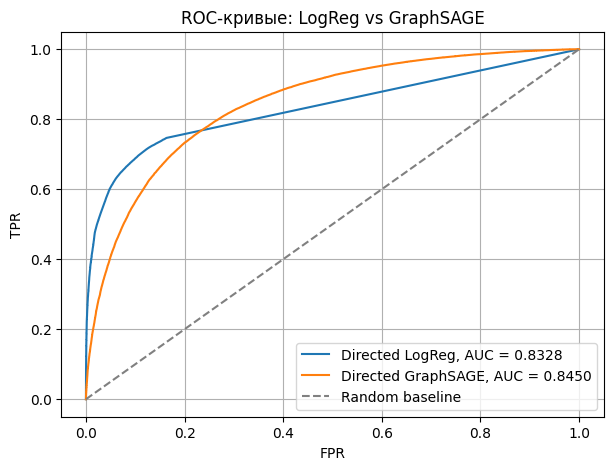

In [32]:
directed_logreg_fpr, directed_logreg_tpr, _ = roc_curve(test_labels, directed_y_score)

directed_gnn_fpr, directed_gnn_tpr, _ = roc_curve(test_labels, directed_gnn_scores)

plt.figure(figsize=(7, 5))
plt.plot(directed_logreg_fpr, directed_logreg_tpr, 
         label=f"Directed LogReg, AUC = {directed_logreg_roc_auc:.4f}")
plt.plot(directed_gnn_fpr, directed_gnn_tpr,
         label=f"Directed GraphSAGE, AUC = {directed_gnn_roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC-кривые: LogReg vs GraphSAGE")
plt.legend()
plt.grid(True)
plt.show()


Этот эксперимент по сути не сильно отличался от 2, т.к. для нашего датасета, если есть ребро $u \rightarrow v$, то скорее всего будет и $v \rightarrow u$, хотя ис другим весом. Т.к. мы не учитываем веса ребер, то ориентированный граф будет близок к неориентированному. 

Тем не менее нам пришлось менять модель и использовать более сложный decoder, из-за чего мы получили сопоставимые результаты для логистической регрессии и GNN.

### 4. Reciprocity


Посмотрим насколько наш ориентированный граф близок к неориентированному. Для этого посчитаем взаимность(reciprocity), т.е. долю ребер имеюих обратные среди всех ребер, а также сделаем это для пар вершин(pair_reciprocity):
$$
\text{pair\_reciprocity} = \frac{|\{\{u,v\} : u \rightarrow v \ \ \text{и} \ \ v \rightarrow u\}|}{|\{\{u,v\} : u \rightarrow v \ \ \text{или} \ \ v \rightarrow u\}|}
$$
$$
\text{reciprocity} = \frac{|\{(u,v) \in G : (v,u) \in G\}|}{|\{(u,v) \in G\}|}
$$

In [19]:
directed_edges = set(G_directed_weighted.edges())
undirected_pairs = set()

for u, v in directed_edges:
    if u != v:
        undirected_pairs.add(tuple(sorted((u, v))))

reciprocal_pairs = set()
reciprocal_directed_edges = 0

for u, v in undirected_pairs:
    if (u, v) in directed_edges and (v, u) in directed_edges:
        reciprocal_pairs.add((u, v))
        reciprocal_directed_edges += 2

pair_reciprocity = len(reciprocal_pairs) / len(undirected_pairs)
reciprocity = reciprocal_directed_edges / len(directed_edges)

print(f"reciprocity: {reciprocity:.4f}")
print(f"pair_reciprocity: {pair_reciprocity:.4f}")


reciprocity: 0.1779
pair_reciprocity: 0.0976


Получаем, что ориентированный граф достаточно далек от неориентированного.

### 5.1. Для теста и валидации возьмем 30% самых больших по весу, ориентированный граф

Сделаем аналогичный эксперимент из пункта 2.1, но для ориентированного графа, будем сравнивать те же модели, что и из пункта 3

In [11]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.1
C_VALUES = [0.01, 0.1, 1.0, 10.0, 100.0]

G_directed = nx.DiGraph()
G_directed.add_nodes_from(G_directed_weighted.nodes())
G_directed.add_edges_from(G_directed_weighted.edges())

In [12]:
def sample_neg_edges_directed(G, n_samples, seed, banned_edges=None):
    rng = random.Random(seed)
    nodes = list(G.nodes())
    neg_edges = set()
    banned_edges = banned_edges or set()

    while len(neg_edges) < n_samples:
        u, v = rng.sample(nodes, 2)
        edge = (u, v)

        if G.has_edge(u, v) or edge in banned_edges:
            continue

        neg_edges.add(edge)

    return list(neg_edges)


In [13]:
def directed_edge_features(G, edges):
    feauteres = []

    for u, v in edges:
        in_u  = set(G.predecessors(u))
        out_u = set(G.successors(u))
        in_v  = set(G.predecessors(v))
        out_v = set(G.successors(v))

        cn_in_set = in_u & in_v
        cn_out_set = out_u & out_v
        cn_in = len(cn_in_set)
        cn_out = len(cn_out_set)
        union_in = len(in_u | in_v)
        union_out = len(out_u | out_v)
        jaccard_in = (cn_in / union_in if union_in > 0 else 0)
        jaccard_out = (cn_out / union_out if union_out > 0 else 0)
        
        aa_in = 0.0

        for x in cn_in_set:
            deg_x = G.in_degree(x) + G.out_degree(x)

            if deg_x > 1:
                aa_in += 1 / np.log(deg_x)
        
        aa_out = 0.0

        for x in cn_out_set:
            deg_x = G.in_degree(x) + G.out_degree(x)

            if deg_x > 1:
                aa_out += 1 / np.log(deg_x)

        feauteres.append([cn_in, cn_out, jaccard_in, jaccard_out, aa_in, aa_out])

    return np.array(feauteres)

In [14]:
def edges_to_ids(edges, node_to_id):
    src = [node_to_id[u] for u, v in edges]
    dst = [node_to_id[v] for u, v in edges]

    return (torch.tensor(src, dtype=torch.long), torch.tensor(dst, dtype=torch.long))

In [15]:
class DirectedGraphSAGELinkPredictor(nn.Module):
    def __init__(self, num_nodes, emb_dim=128, hidden_dim=128, 
                 out_dim=64, decoder_hidden_dim=128, dropout=0.2):
        super().__init__()

        self.embedding = nn.Embedding(num_nodes, emb_dim)
        self.conv1 = SAGEConv(emb_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)

        self.decoder = nn.Sequential(
            nn.Linear(2 * out_dim, decoder_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(decoder_hidden_dim, 1)
        )

    def encode(self, edge_index):
        x = self.embedding.weight
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = self.conv2(h, edge_index)

        return h
    
    def decode(self, z, edge_label_index):
        src = edge_label_index[0]
        dst = edge_label_index[1]
        pair = torch.cat([z[src], z[dst]], dim=1)

        return self.decoder(pair).squeeze(-1)
    
    def forward(self, edge_index, edge_label_index):
        z = self.encode(edge_index)
        scores = self.decode(z, edge_label_index)

        return scores



In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [17]:
directed_edge_weights = {}

for u, v, edge_data in G_directed_weighted.edges(data=True):
    directed_edge_weights[(u, v)] = float(edge_data['R1.Strength'])


In [18]:
sorted_w_directed_edges = sorted(directed_edge_weights.items(), key=lambda x: x[1], reverse=True)

n_strong = int(len(sorted_w_directed_edges) * (TEST_SIZE + VAL_SIZE))
strong_directed_edges = [edge for edge, weight in sorted_w_directed_edges[:n_strong]]
train_pos_edges = [edge for edge, weight in sorted_w_directed_edges[n_strong:]]

val_pos_edges, test_pos_edges = train_test_split(
    strong_directed_edges,
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    random_state=RANDOM_STATE,
    shuffle=True
)

print("Positive directed edges:")
print("train:", len(train_pos_edges))
print("val:", len(val_pos_edges))
print("test:", len(test_pos_edges))


Positive directed edges:
train: 270770
val: 38681
test: 77362


In [19]:
G_directed = nx.DiGraph()
G_directed.add_nodes_from(G_directed_weighted.nodes())
G_directed.add_edges_from(G_directed_weighted.edges())

train_neg_edges = sample_neg_edges_directed(
    G_directed,
    n_samples=len(train_pos_edges),
    seed=RANDOM_STATE + 1
)

val_neg_edges = sample_neg_edges_directed(
    G_directed,
    n_samples=len(val_pos_edges),
    seed=RANDOM_STATE + 2,
    banned_edges=set(train_neg_edges)
)

test_neg_edges = sample_neg_edges_directed(
    G_directed,
    n_samples=len(test_pos_edges),
    seed=RANDOM_STATE + 3,
    banned_edges=set(train_neg_edges) | set(val_neg_edges)
)

print("Negative directed edges:")
print("train:", len(train_neg_edges))
print("val:", len(val_neg_edges))
print("test:", len(test_neg_edges))


Negative directed edges:
train: 270770
val: 38681
test: 77362


In [20]:
train_edges = train_pos_edges + train_neg_edges
train_labels = np.array([1] * len(train_pos_edges) + [0] * len(train_neg_edges))

val_edges = val_pos_edges + val_neg_edges
val_labels = np.array([1] * len(val_pos_edges) + [0] * len(val_neg_edges))

test_edges = test_pos_edges + test_neg_edges
test_labels = np.array([1] * len(test_pos_edges) + [0] * len(test_neg_edges))

G_train_directed = nx.DiGraph()
G_train_directed.add_nodes_from(G_directed.nodes())
G_train_directed.add_edges_from(train_pos_edges)

print("G_train_directed nodes:", G_train_directed.number_of_nodes())
print("G_train_directed edges:", G_train_directed.number_of_edges())


G_train_directed nodes: 12217
G_train_directed edges: 270770


In [21]:
X_train = directed_edge_features(G_train_directed, train_edges)
X_val = directed_edge_features(G_train_directed, val_edges)
X_test = directed_edge_features(G_train_directed, test_edges)

print(X_train.shape, train_labels.shape)
print(X_val.shape, val_labels.shape)
print(X_test.shape, test_labels.shape)


(541540, 6) (541540,)
(77362, 6) (77362,)
(154724, 6) (154724,)


In [22]:
C_VALUES = [0.01, 0.1, 1.0, 10.0, 100.0]

directed_logreg_results_strong = []
best_c_directed_strong = None
best_directed_val_auc_strong = -1.0
directed_baseline_model_strong = None

for c_value in C_VALUES:
    candidate_model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            C=c_value,
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])

    candidate_model.fit(X_train, train_labels)
    val_score = candidate_model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(val_labels, val_score)
    val_ap = average_precision_score(val_labels, val_score)

    directed_logreg_results_strong.append({
        "C": c_value,
        "val_roc_auc": val_auc,
        "val_average_precision": val_ap
    })

    if val_auc > best_directed_val_auc_strong:
        best_directed_val_auc_strong = val_auc
        best_c_directed_strong = c_value
        directed_baseline_model_strong = candidate_model

directed_logreg_results_strong = pd.DataFrame(directed_logreg_results_strong)
directed_logreg_results_strong


,C,val_roc_auc,val_average_precision
0,0.01,0.841607,0.850379
1,0.10,0.841714,0.850559
2,1.00,0.841725,0.850578
3,10.00,0.841726,0.850580
4,100.00,0.841726,0.850580


In [23]:
print(f"Best C: {best_c_directed_strong}")
print(f"Best validation ROC-AUC: {best_directed_val_auc_strong:.4f}")


Best C: 100.0
Best validation ROC-AUC: 0.8417


In [24]:
directed_y_score_strong = directed_baseline_model_strong.predict_proba(X_test)[:, 1]
directed_y_pred_strong = (directed_y_score_strong >= 0.5).astype(int)

directed_logreg_roc_auc_strong = roc_auc_score(test_labels, directed_y_score_strong)
directed_logreg_avg_precision_strong = average_precision_score(test_labels, directed_y_score_strong)
directed_logreg_accuracy_strong = accuracy_score(test_labels, directed_y_pred_strong)
directed_logreg_f1_strong = f1_score(test_labels, directed_y_pred_strong)

print(f"Directed LogReg Test ROC-AUC: {directed_logreg_roc_auc_strong:.4f}")
print(f"Directed LogReg Test Average Precision: {directed_logreg_avg_precision_strong:.4f}")
print(f"Directed LogReg Test Accuracy, порог=0.5: {directed_logreg_accuracy_strong:.4f}")
print(f"Directed LogReg Test F1-score, порог=0.5: {directed_logreg_f1_strong:.4f}")


Directed LogReg Test ROC-AUC: 0.8399
Directed LogReg Test Average Precision: 0.8494
Directed LogReg Test Accuracy, порог=0.5: 0.8045
Directed LogReg Test F1-score, порог=0.5: 0.7894


In [ ]:
nodes = list(G_train_directed.nodes())
### 5.1. Для теста и валидации возьмем 30% самых больших по весу, ориентированный граф
node_to_id = {node: i for i, node in enumerate(nodes)}
id_to_node = {i: node for node, i in node_to_id.items()}
num_nodes = len(nodes)

print("Количество вершин:", num_nodes)


Количество вершин: 12217


In [26]:
graph_edges = list(G_train_directed.edges())
graph_src, graph_dst = edges_to_ids(graph_edges, node_to_id)

directed_edge_index = torch.stack([graph_src, graph_dst], dim=0)

strong_directed_data = Data(
    edge_index=directed_edge_index,
    num_nodes=num_nodes
)

print(strong_directed_data)


Data(edge_index=[2, 270770], num_nodes=12217)


In [27]:
train_src, train_dst = edges_to_ids(train_edges, node_to_id)
val_src, val_dst = edges_to_ids(val_edges, node_to_id)
test_src, test_dst = edges_to_ids(test_edges, node_to_id)

train_edge_index = torch.stack([train_src, train_dst], dim=0)
val_edge_index = torch.stack([val_src, val_dst], dim=0)
test_edge_index = torch.stack([test_src, test_dst], dim=0)

train_y = torch.tensor(train_labels, dtype=torch.float32)
val_y = torch.tensor(val_labels, dtype=torch.float32)
test_y = torch.tensor(test_labels, dtype=torch.float32)

print(train_edge_index.shape, train_y.shape)
print(val_edge_index.shape, val_y.shape)
print(test_edge_index.shape, test_y.shape)


torch.Size([2, 541540]) torch.Size([541540])
torch.Size([2, 77362]) torch.Size([77362])
torch.Size([2, 154724]) torch.Size([154724])


In [28]:
strong_directed_data = strong_directed_data.to(device)

train_edge_index = train_edge_index.to(device)
val_edge_index = val_edge_index.to(device)
test_edge_index = test_edge_index.to(device)

train_y = train_y.to(device)
val_y = val_y.to(device)
test_y = test_y.to(device)

directed_gnn_model_strong = DirectedGraphSAGELinkPredictor(
    num_nodes=num_nodes,
    emb_dim=128,
    hidden_dim=128,
    out_dim=64,
    decoder_hidden_dim=128,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(
    directed_gnn_model_strong.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

loss_func = nn.BCEWithLogitsLoss()


In [29]:
EPOCH_NUM = 10000
EVAL_EVERY = 50
PATIENCE = 500

best_val_auc = 0.0
best_val_ap = 0.0
best_epoch = 0
best_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCH_NUM + 1):
    directed_gnn_model_strong.train()
    optimizer.zero_grad()

    logits = directed_gnn_model_strong(strong_directed_data.edge_index, train_edge_index)
    loss = loss_func(logits, train_y)

    loss.backward()
    optimizer.step()

    if epoch % EVAL_EVERY == 0:
        directed_gnn_model_strong.eval()

        with torch.no_grad():
            val_logits = directed_gnn_model_strong(strong_directed_data.edge_index, val_edge_index)
            val_scores = torch.sigmoid(val_logits).detach().cpu().numpy()

        val_auc = roc_auc_score(val_labels, val_scores)
        val_ap = average_precision_score(val_labels, val_scores)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_val_ap = val_ap
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in directed_gnn_model_strong.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += EVAL_EVERY

        print(
            f"Epoch {epoch:05d} | "
            f"Loss: {loss.item():.4f} | "
            f"Val ROC-AUC: {val_auc:.4f} | "
            f"Val AP: {val_ap:.4f} | "
            f"Best val ROC-AUC: {best_val_auc:.4f} at epoch {best_epoch}"
        )

        if epochs_without_improvement >= PATIENCE:
            print(f"Stopped at epoch {epoch}")
            break

if best_state is not None:
    directed_gnn_model_strong.load_state_dict(best_state)
    directed_gnn_model_strong = directed_gnn_model_strong.to(device)
    print(f"Best model from epoch {best_epoch}")


Epoch 00050 | Loss: 0.5975 | Val ROC-AUC: 0.7627 | Val AP: 0.7631 | Best val ROC-AUC: 0.7627 at epoch 50
Epoch 00100 | Loss: 0.5478 | Val ROC-AUC: 0.8116 | Val AP: 0.8151 | Best val ROC-AUC: 0.8116 at epoch 100
Epoch 00150 | Loss: 0.5388 | Val ROC-AUC: 0.8158 | Val AP: 0.8189 | Best val ROC-AUC: 0.8158 at epoch 150
Epoch 00200 | Loss: 0.5343 | Val ROC-AUC: 0.8157 | Val AP: 0.8184 | Best val ROC-AUC: 0.8158 at epoch 150
Epoch 00250 | Loss: 0.5277 | Val ROC-AUC: 0.8139 | Val AP: 0.8159 | Best val ROC-AUC: 0.8158 at epoch 150
Epoch 00300 | Loss: 0.5195 | Val ROC-AUC: 0.8117 | Val AP: 0.8131 | Best val ROC-AUC: 0.8158 at epoch 150
Epoch 00350 | Loss: 0.5116 | Val ROC-AUC: 0.8097 | Val AP: 0.8107 | Best val ROC-AUC: 0.8158 at epoch 150
Epoch 00400 | Loss: 0.5037 | Val ROC-AUC: 0.8090 | Val AP: 0.8093 | Best val ROC-AUC: 0.8158 at epoch 150
Epoch 00450 | Loss: 0.4955 | Val ROC-AUC: 0.8087 | Val AP: 0.8085 | Best val ROC-AUC: 0.8158 at epoch 150
Epoch 00500 | Loss: 0.4846 | Val ROC-AUC: 0.812

In [30]:
directed_gnn_model_strong.eval()

with torch.no_grad():
    test_logits = directed_gnn_model_strong(strong_directed_data.edge_index, test_edge_index)
    directed_gnn_scores_strong = torch.sigmoid(test_logits).detach().cpu().numpy()

directed_gnn_pred_strong = (directed_gnn_scores_strong >= 0.5).astype(int)

directed_gnn_roc_auc_strong = roc_auc_score(test_labels, directed_gnn_scores_strong)
directed_gnn_avg_precision_strong = average_precision_score(test_labels, directed_gnn_scores_strong)
directed_gnn_accuracy_strong = accuracy_score(test_labels, directed_gnn_pred_strong)
directed_gnn_f1_strong = f1_score(test_labels, directed_gnn_pred_strong)

print(f"Best validation epoch: {best_epoch}")
print(f"Best validation ROC-AUC: {best_val_auc:.4f}")
print(f"Best validation Average Precision: {best_val_ap:.4f}")
print(f"Directed GNN Test ROC-AUC: {directed_gnn_roc_auc_strong:.4f}")
print(f"Directed GNN Test Average Precision: {directed_gnn_avg_precision_strong:.4f}")
print(f"Directed GNN Test Accuracy: {directed_gnn_accuracy_strong:.4f}")
print(f"Directed GNN Test F1-score: {directed_gnn_f1_strong:.4f}")


Best validation epoch: 1500
Best validation ROC-AUC: 0.8546
Best validation Average Precision: 0.8465
Directed GNN Test ROC-AUC: 0.8532
Directed GNN Test Average Precision: 0.8463
Directed GNN Test Accuracy: 0.7764
Directed GNN Test F1-score: 0.7834


In [31]:
strong_directed_edges_results = pd.DataFrame([
    {
        "model": "Directed LogReg",
        "roc_auc": directed_logreg_roc_auc_strong,
        "average_precision": directed_logreg_avg_precision_strong,
        "accuracy": directed_logreg_accuracy_strong,
        "f1": directed_logreg_f1_strong,
    },
    {
        "model": "Directed GraphSAGE",
        "roc_auc": directed_gnn_roc_auc_strong,
        "average_precision": directed_gnn_avg_precision_strong,
        "accuracy": directed_gnn_accuracy_strong,
        "f1": directed_gnn_f1_strong,
    }
])

strong_directed_edges_results.round(4)


,model,roc_auc,average_precision,accuracy,f1
0,Directed LogReg,0.8399,0.8494,0.8045,0.7894
1,Directed GraphSAGE,0.8532,0.8463,0.7764,0.7834


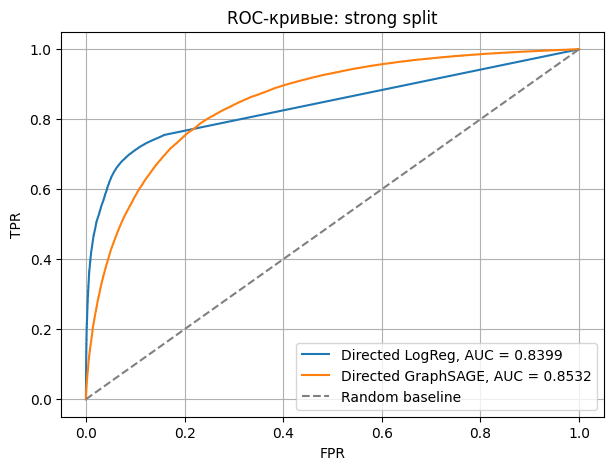

In [34]:
directed_logreg_fpr_strong, directed_logreg_tpr_strong, _ = roc_curve(test_labels, directed_y_score_strong)
directed_gnn_fpr_strong, directed_gnn_tpr_strong, _ = roc_curve(test_labels, directed_gnn_scores_strong)

plt.figure(figsize=(7, 5))
plt.plot(
    directed_logreg_fpr_strong,
    directed_logreg_tpr_strong,
    label=f"Directed LogReg, AUC = {directed_logreg_roc_auc_strong:.4f}"
)
plt.plot(
    directed_gnn_fpr_strong,
    directed_gnn_tpr_strong,
    label=f"Directed GraphSAGE, AUC = {directed_gnn_roc_auc_strong:.4f}"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC-кривые: strong split")
plt.legend()
plt.grid(True)
plt.show()


Здесь видим результат, схожий с тем, что получили в пункте 3.

### 5.2. Для теста и валидации возьмем 30% самых маленьких по весу, ориентированный граф

Сделаем аналогичный эксперимент из пункта 2.2, но для ориентированного графа.


In [6]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.1
C_VALUES = [0.01, 0.1, 1.0, 10.0, 100.0]

G_directed = nx.DiGraph()
G_directed.add_nodes_from(G_directed_weighted.nodes())
G_directed.add_edges_from(G_directed_weighted.edges())


In [7]:
def sample_neg_edges_directed(G, n_samples, seed, banned_edges=None):
    rng = random.Random(seed)
    nodes = list(G.nodes())
    neg_edges = set()
    banned_edges = banned_edges or set()

    while len(neg_edges) < n_samples:
        u, v = rng.sample(nodes, 2)
        edge = (u, v)

        if G.has_edge(u, v) or edge in banned_edges:
            continue

        neg_edges.add(edge)

    return list(neg_edges)


In [8]:
def directed_edge_features(G, edges):
    feauteres = []

    for u, v in edges:
        in_u  = set(G.predecessors(u))
        out_u = set(G.successors(u))
        in_v  = set(G.predecessors(v))
        out_v = set(G.successors(v))

        cn_in_set = in_u & in_v
        cn_out_set = out_u & out_v
        cn_in = len(cn_in_set)
        cn_out = len(cn_out_set)
        union_in = len(in_u | in_v)
        union_out = len(out_u | out_v)
        jaccard_in = (cn_in / union_in if union_in > 0 else 0)
        jaccard_out = (cn_out / union_out if union_out > 0 else 0)
        
        aa_in = 0.0

        for x in cn_in_set:
            deg_x = G.in_degree(x) + G.out_degree(x)

            if deg_x > 1:
                aa_in += 1 / np.log(deg_x)
        
        aa_out = 0.0

        for x in cn_out_set:
            deg_x = G.in_degree(x) + G.out_degree(x)

            if deg_x > 1:
                aa_out += 1 / np.log(deg_x)

        feauteres.append([cn_in, cn_out, jaccard_in, jaccard_out, aa_in, aa_out])

    return np.array(feauteres)


In [9]:
def edges_to_ids(edges, node_to_id):
    src = [node_to_id[u] for u, v in edges]
    dst = [node_to_id[v] for u, v in edges]

    return (torch.tensor(src, dtype=torch.long), torch.tensor(dst, dtype=torch.long))


In [10]:
class DirectedGraphSAGELinkPredictor(nn.Module):
    def __init__(self, num_nodes, emb_dim=128, hidden_dim=128, 
                 out_dim=64, decoder_hidden_dim=128, dropout=0.2):
        super().__init__()

        self.embedding = nn.Embedding(num_nodes, emb_dim)
        self.conv1 = SAGEConv(emb_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)

        self.decoder = nn.Sequential(
            nn.Linear(2 * out_dim, decoder_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(decoder_hidden_dim, 1)
        )

    def encode(self, edge_index):
        x = self.embedding.weight
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = self.conv2(h, edge_index)

        return h
    
    def decode(self, z, edge_label_index):
        src = edge_label_index[0]
        dst = edge_label_index[1]
        pair = torch.cat([z[src], z[dst]], dim=1)

        return self.decoder(pair).squeeze(-1)
    
    def forward(self, edge_index, edge_label_index):
        z = self.encode(edge_index)
        scores = self.decode(z, edge_label_index)

        return scores


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [12]:
directed_edge_weights = {}

for u, v, edge_data in G_directed_weighted.edges(data=True):
    directed_edge_weights[(u, v)] = float(edge_data['R1.Strength'])


In [13]:
sorted_w_directed_edges = sorted(directed_edge_weights.items(), key=lambda x: x[1], reverse=True)

n_weak = int(len(sorted_w_directed_edges) * (TEST_SIZE + VAL_SIZE))
weak_directed_edges = [edge for edge, weight in sorted_w_directed_edges[-n_weak:]]
train_pos_edges = [edge for edge, weight in sorted_w_directed_edges[:-n_weak]]

val_pos_edges, test_pos_edges = train_test_split(
    weak_directed_edges,
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    random_state=RANDOM_STATE,
    shuffle=True
)

print("Weak positive directed edges:", len(weak_directed_edges))
print("Train positive directed edges:", len(train_pos_edges))
print("Validation positive directed edges:", len(val_pos_edges))
print("Test positive directed edges:", len(test_pos_edges))


Weak positive directed edges: 116043
Train positive directed edges: 270770
Validation positive directed edges: 38681
Test positive directed edges: 77362


In [14]:
train_neg_edges = sample_neg_edges_directed(
    G_directed,
    n_samples=len(train_pos_edges),
    seed=RANDOM_STATE + 1
)

val_neg_edges = sample_neg_edges_directed(
    G_directed,
    n_samples=len(val_pos_edges),
    seed=RANDOM_STATE + 2,
    banned_edges=set(train_neg_edges)
)

test_neg_edges = sample_neg_edges_directed(
    G_directed,
    n_samples=len(test_pos_edges),
    seed=RANDOM_STATE + 3,
    banned_edges=set(train_neg_edges) | set(val_neg_edges)
)

print("Negative directed edges:")
print("train:", len(train_neg_edges))
print("val:", len(val_neg_edges))
print("test:", len(test_neg_edges))


Negative directed edges:
train: 270770
val: 38681
test: 77362


In [15]:
train_edges = train_pos_edges + train_neg_edges
train_labels = np.array([1] * len(train_pos_edges) + [0] * len(train_neg_edges))

val_edges = val_pos_edges + val_neg_edges
val_labels = np.array([1] * len(val_pos_edges) + [0] * len(val_neg_edges))

test_edges = test_pos_edges + test_neg_edges
test_labels = np.array([1] * len(test_pos_edges) + [0] * len(test_neg_edges))

G_train_directed = nx.DiGraph()
G_train_directed.add_nodes_from(G_directed.nodes())
G_train_directed.add_edges_from(train_pos_edges)

print("Train labels:", np.bincount(train_labels))
print("Validation labels:", np.bincount(val_labels))
print("Test labels:", np.bincount(test_labels))
print("G_train_directed nodes:", G_train_directed.number_of_nodes())
print("G_train_directed edges:", G_train_directed.number_of_edges())


Train labels: [270770 270770]
Validation labels: [38681 38681]
Test labels: [77362 77362]
G_train_directed nodes: 12217
G_train_directed edges: 270770


Теперь обучим логистическую регрессию на directed structural features.


In [16]:
X_train = directed_edge_features(G_train_directed, train_edges)
X_val = directed_edge_features(G_train_directed, val_edges)
X_test = directed_edge_features(G_train_directed, test_edges)

print(X_train.shape, train_labels.shape)
print(X_val.shape, val_labels.shape)
print(X_test.shape, test_labels.shape)


(541540, 6) (541540,)
(77362, 6) (77362,)
(154724, 6) (154724,)


In [17]:
directed_logreg_results_weak = []
best_c_directed_weak = None
best_directed_val_auc_weak = -1.0
directed_baseline_model_weak = None

for c_value in C_VALUES:
    candidate_model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            C=c_value,
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])

    candidate_model.fit(X_train, train_labels)
    val_score = candidate_model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(val_labels, val_score)
    val_ap = average_precision_score(val_labels, val_score)

    directed_logreg_results_weak.append({
        "C": c_value,
        "val_roc_auc": val_auc,
        "val_average_precision": val_ap
    })

    if val_auc > best_directed_val_auc_weak:
        best_directed_val_auc_weak = val_auc
        best_c_directed_weak = c_value
        directed_baseline_model_weak = candidate_model

directed_logreg_results_weak = pd.DataFrame(directed_logreg_results_weak)
directed_logreg_results_weak


,C,val_roc_auc,val_average_precision
0,0.01,0.783758,0.794284
1,0.10,0.783561,0.794127
2,1.00,0.783540,0.794120
3,10.00,0.783537,0.794119
4,100.00,0.783537,0.794119


In [18]:
print(f"Best C: {best_c_directed_weak}")
print(f"Best validation ROC-AUC: {best_directed_val_auc_weak:.4f}")


Best C: 0.01
Best validation ROC-AUC: 0.7838


In [19]:
directed_y_score_weak = directed_baseline_model_weak.predict_proba(X_test)[:, 1]
directed_y_pred_weak = (directed_y_score_weak >= 0.5).astype(int)

directed_logreg_roc_auc_weak = roc_auc_score(test_labels, directed_y_score_weak)
directed_logreg_avg_precision_weak = average_precision_score(test_labels, directed_y_score_weak)
directed_logreg_accuracy_weak = accuracy_score(test_labels, directed_y_pred_weak)
directed_logreg_f1_weak = f1_score(test_labels, directed_y_pred_weak)

print(f"Directed LogReg Test ROC-AUC: {directed_logreg_roc_auc_weak:.4f}")
print(f"Directed LogReg Test Average Precision: {directed_logreg_avg_precision_weak:.4f}")
print(f"Directed LogReg Test Accuracy, порог=0.5: {directed_logreg_accuracy_weak:.4f}")
print(f"Directed LogReg Test F1-score, порог=0.5: {directed_logreg_f1_weak:.4f}")


Directed LogReg Test ROC-AUC: 0.7818
Directed LogReg Test Average Precision: 0.7927
Directed LogReg Test Accuracy, порог=0.5: 0.7603
Directed LogReg Test F1-score, порог=0.5: 0.7162


In [20]:
nodes = list(G_train_directed.nodes())

node_to_id = {node: i for i, node in enumerate(nodes)}
id_to_node = {i: node for node, i in node_to_id.items()}
num_nodes = len(nodes)

print("Количество вершин:", num_nodes)


Количество вершин: 12217


In [21]:
graph_edges = list(G_train_directed.edges())
graph_src, graph_dst = edges_to_ids(graph_edges, node_to_id)

directed_edge_index = torch.stack([graph_src, graph_dst], dim=0)

weak_directed_data = Data(
    edge_index=directed_edge_index,
    num_nodes=num_nodes
)

print(weak_directed_data)


Data(edge_index=[2, 270770], num_nodes=12217)


In [22]:
train_src, train_dst = edges_to_ids(train_edges, node_to_id)
val_src, val_dst = edges_to_ids(val_edges, node_to_id)
test_src, test_dst = edges_to_ids(test_edges, node_to_id)

train_edge_index = torch.stack([train_src, train_dst], dim=0)
val_edge_index = torch.stack([val_src, val_dst], dim=0)
test_edge_index = torch.stack([test_src, test_dst], dim=0)

train_y = torch.tensor(train_labels, dtype=torch.float32)
val_y = torch.tensor(val_labels, dtype=torch.float32)
test_y = torch.tensor(test_labels, dtype=torch.float32)

print(train_edge_index.shape, train_y.shape)
print(val_edge_index.shape, val_y.shape)
print(test_edge_index.shape, test_y.shape)


torch.Size([2, 541540]) torch.Size([541540])
torch.Size([2, 77362]) torch.Size([77362])
torch.Size([2, 154724]) torch.Size([154724])


In [23]:
weak_directed_data = weak_directed_data.to(device)

train_edge_index = train_edge_index.to(device)
val_edge_index = val_edge_index.to(device)
test_edge_index = test_edge_index.to(device)

train_y = train_y.to(device)
val_y = val_y.to(device)
test_y = test_y.to(device)

directed_gnn_model_weak = DirectedGraphSAGELinkPredictor(
    num_nodes=num_nodes,
    emb_dim=128,
    hidden_dim=128,
    out_dim=64,
    decoder_hidden_dim=128,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(
    directed_gnn_model_weak.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

loss_func = nn.BCEWithLogitsLoss()


In [24]:
EPOCH_NUM = 10000
EVAL_EVERY = 50
PATIENCE = 500

best_val_auc = 0.0
best_val_ap = 0.0
best_epoch = 0
best_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCH_NUM + 1):
    directed_gnn_model_weak.train()
    optimizer.zero_grad()

    logits = directed_gnn_model_weak(weak_directed_data.edge_index, train_edge_index)
    loss = loss_func(logits, train_y)

    loss.backward()
    optimizer.step()

    if epoch % EVAL_EVERY == 0:
        directed_gnn_model_weak.eval()

        with torch.no_grad():
            val_logits = directed_gnn_model_weak(weak_directed_data.edge_index, val_edge_index)
            val_scores = torch.sigmoid(val_logits).detach().cpu().numpy()

        val_auc = roc_auc_score(val_labels, val_scores)
        val_ap = average_precision_score(val_labels, val_scores)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_val_ap = val_ap
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in directed_gnn_model_weak.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += EVAL_EVERY

        print(
            f"Epoch {epoch:05d} | "
            f"Loss: {loss.item():.4f} | "
            f"Val ROC-AUC: {val_auc:.4f} | "
            f"Val AP: {val_ap:.4f} | "
            f"Best val ROC-AUC: {best_val_auc:.4f} at epoch {best_epoch}"
        )

        if epochs_without_improvement >= PATIENCE:
            print(f"Stopped at epoch {epoch}")
            break

if best_state is not None:
    directed_gnn_model_weak.load_state_dict(best_state)
    directed_gnn_model_weak = directed_gnn_model_weak.to(device)
    print(f"Best model from epoch {best_epoch}")


Epoch 00050 | Loss: 0.5933 | Val ROC-AUC: 0.7194 | Val AP: 0.7200 | Best val ROC-AUC: 0.7194 at epoch 50
Epoch 00100 | Loss: 0.5292 | Val ROC-AUC: 0.7690 | Val AP: 0.7712 | Best val ROC-AUC: 0.7690 at epoch 100
Epoch 00150 | Loss: 0.5142 | Val ROC-AUC: 0.7559 | Val AP: 0.7566 | Best val ROC-AUC: 0.7690 at epoch 100
Epoch 00200 | Loss: 0.5021 | Val ROC-AUC: 0.7281 | Val AP: 0.7250 | Best val ROC-AUC: 0.7690 at epoch 100
Epoch 00250 | Loss: 0.4926 | Val ROC-AUC: 0.7030 | Val AP: 0.6976 | Best val ROC-AUC: 0.7690 at epoch 100
Epoch 00300 | Loss: 0.4855 | Val ROC-AUC: 0.6856 | Val AP: 0.6799 | Best val ROC-AUC: 0.7690 at epoch 100
Epoch 00350 | Loss: 0.4806 | Val ROC-AUC: 0.6785 | Val AP: 0.6734 | Best val ROC-AUC: 0.7690 at epoch 100
Epoch 00400 | Loss: 0.4768 | Val ROC-AUC: 0.6744 | Val AP: 0.6696 | Best val ROC-AUC: 0.7690 at epoch 100
Epoch 00450 | Loss: 0.4710 | Val ROC-AUC: 0.6770 | Val AP: 0.6718 | Best val ROC-AUC: 0.7690 at epoch 100
Epoch 00500 | Loss: 0.4564 | Val ROC-AUC: 0.689

In [25]:
directed_gnn_model_weak.eval()

with torch.no_grad():
    test_logits = directed_gnn_model_weak(weak_directed_data.edge_index, test_edge_index)
    directed_gnn_scores_weak = torch.sigmoid(test_logits).detach().cpu().numpy()

directed_gnn_pred_weak = (directed_gnn_scores_weak >= 0.5).astype(int)

directed_gnn_roc_auc_weak = roc_auc_score(test_labels, directed_gnn_scores_weak)
directed_gnn_avg_precision_weak = average_precision_score(test_labels, directed_gnn_scores_weak)
directed_gnn_accuracy_weak = accuracy_score(test_labels, directed_gnn_pred_weak)
directed_gnn_f1_weak = f1_score(test_labels, directed_gnn_pred_weak)

print(f"Best validation epoch: {best_epoch}")
print(f"Best validation ROC-AUC: {best_val_auc:.4f}")
print(f"Best validation Average Precision: {best_val_ap:.4f}")
print(f"Directed GNN Test ROC-AUC: {directed_gnn_roc_auc_weak:.4f}")
print(f"Directed GNN Test Average Precision: {directed_gnn_avg_precision_weak:.4f}")
print(f"Directed GNN Test Accuracy: {directed_gnn_accuracy_weak:.4f}")
print(f"Directed GNN Test F1-score: {directed_gnn_f1_weak:.4f}")


Best validation epoch: 100
Best validation ROC-AUC: 0.7690
Best validation Average Precision: 0.7712
Directed GNN Test ROC-AUC: 0.7696
Directed GNN Test Average Precision: 0.7734
Directed GNN Test Accuracy: 0.7058
Directed GNN Test F1-score: 0.6975


In [26]:
weak_directed_edges_results = pd.DataFrame([
    {
        "model": "Directed LogReg",
        "roc_auc": directed_logreg_roc_auc_weak,
        "average_precision": directed_logreg_avg_precision_weak,
        "accuracy": directed_logreg_accuracy_weak,
        "f1": directed_logreg_f1_weak,
    },
    {
        "model": "Directed GraphSAGE",
        "roc_auc": directed_gnn_roc_auc_weak,
        "average_precision": directed_gnn_avg_precision_weak,
        "accuracy": directed_gnn_accuracy_weak,
        "f1": directed_gnn_f1_weak,
    }
])

weak_directed_edges_results.round(4)


,model,roc_auc,average_precision,accuracy,f1
0,Directed LogReg,0.7818,0.7927,0.7603,0.7162
1,Directed GraphSAGE,0.7696,0.7734,0.7058,0.6975


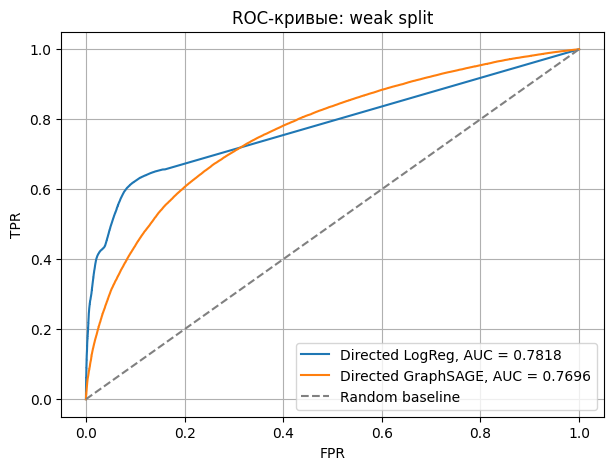

In [28]:
directed_logreg_fpr_weak, directed_logreg_tpr_weak, _ = roc_curve(test_labels, directed_y_score_weak)
directed_gnn_fpr_weak, directed_gnn_tpr_weak, _ = roc_curve(test_labels, directed_gnn_scores_weak)

plt.figure(figsize=(7, 5))
plt.plot(
    directed_logreg_fpr_weak,
    directed_logreg_tpr_weak,
    label=f"Directed LogReg, AUC = {directed_logreg_roc_auc_weak:.4f}"
)
plt.plot(
    directed_gnn_fpr_weak,
    directed_gnn_tpr_weak,
    label=f"Directed GraphSAGE, AUC = {directed_gnn_roc_auc_weak:.4f}"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC-кривые: weak split")
plt.legend()
plt.grid(True)
plt.show()


Здесь обе модели по метрике стали хуже, при этом в случайном разбиении AUC был выше у GNN, однако здесь у логистической регресии выше.